CSV path:
/home/ustc1958/lxy/graph/tone/complete_package0614/wu_vowel_segments.f1f2_per_audio.csv

Output directory:
/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid

Cleaned rows from all 14 regions: 43,905

Saved metric files:
/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/region_summary_14regions.csv
/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/region_vowel_summary_14regions_9vowels.csv
Region summary rows: 14
Region-vowel summary rows: 126

Regions used in the figure:
01当涂  Dangtu
02芜湖  Wuhu
03池州  Chizhou
04青阳  Qingyang
05石台  Shitai
06铜陵  Tongling
07宣城  Xuancheng
08泾县  Jingxian


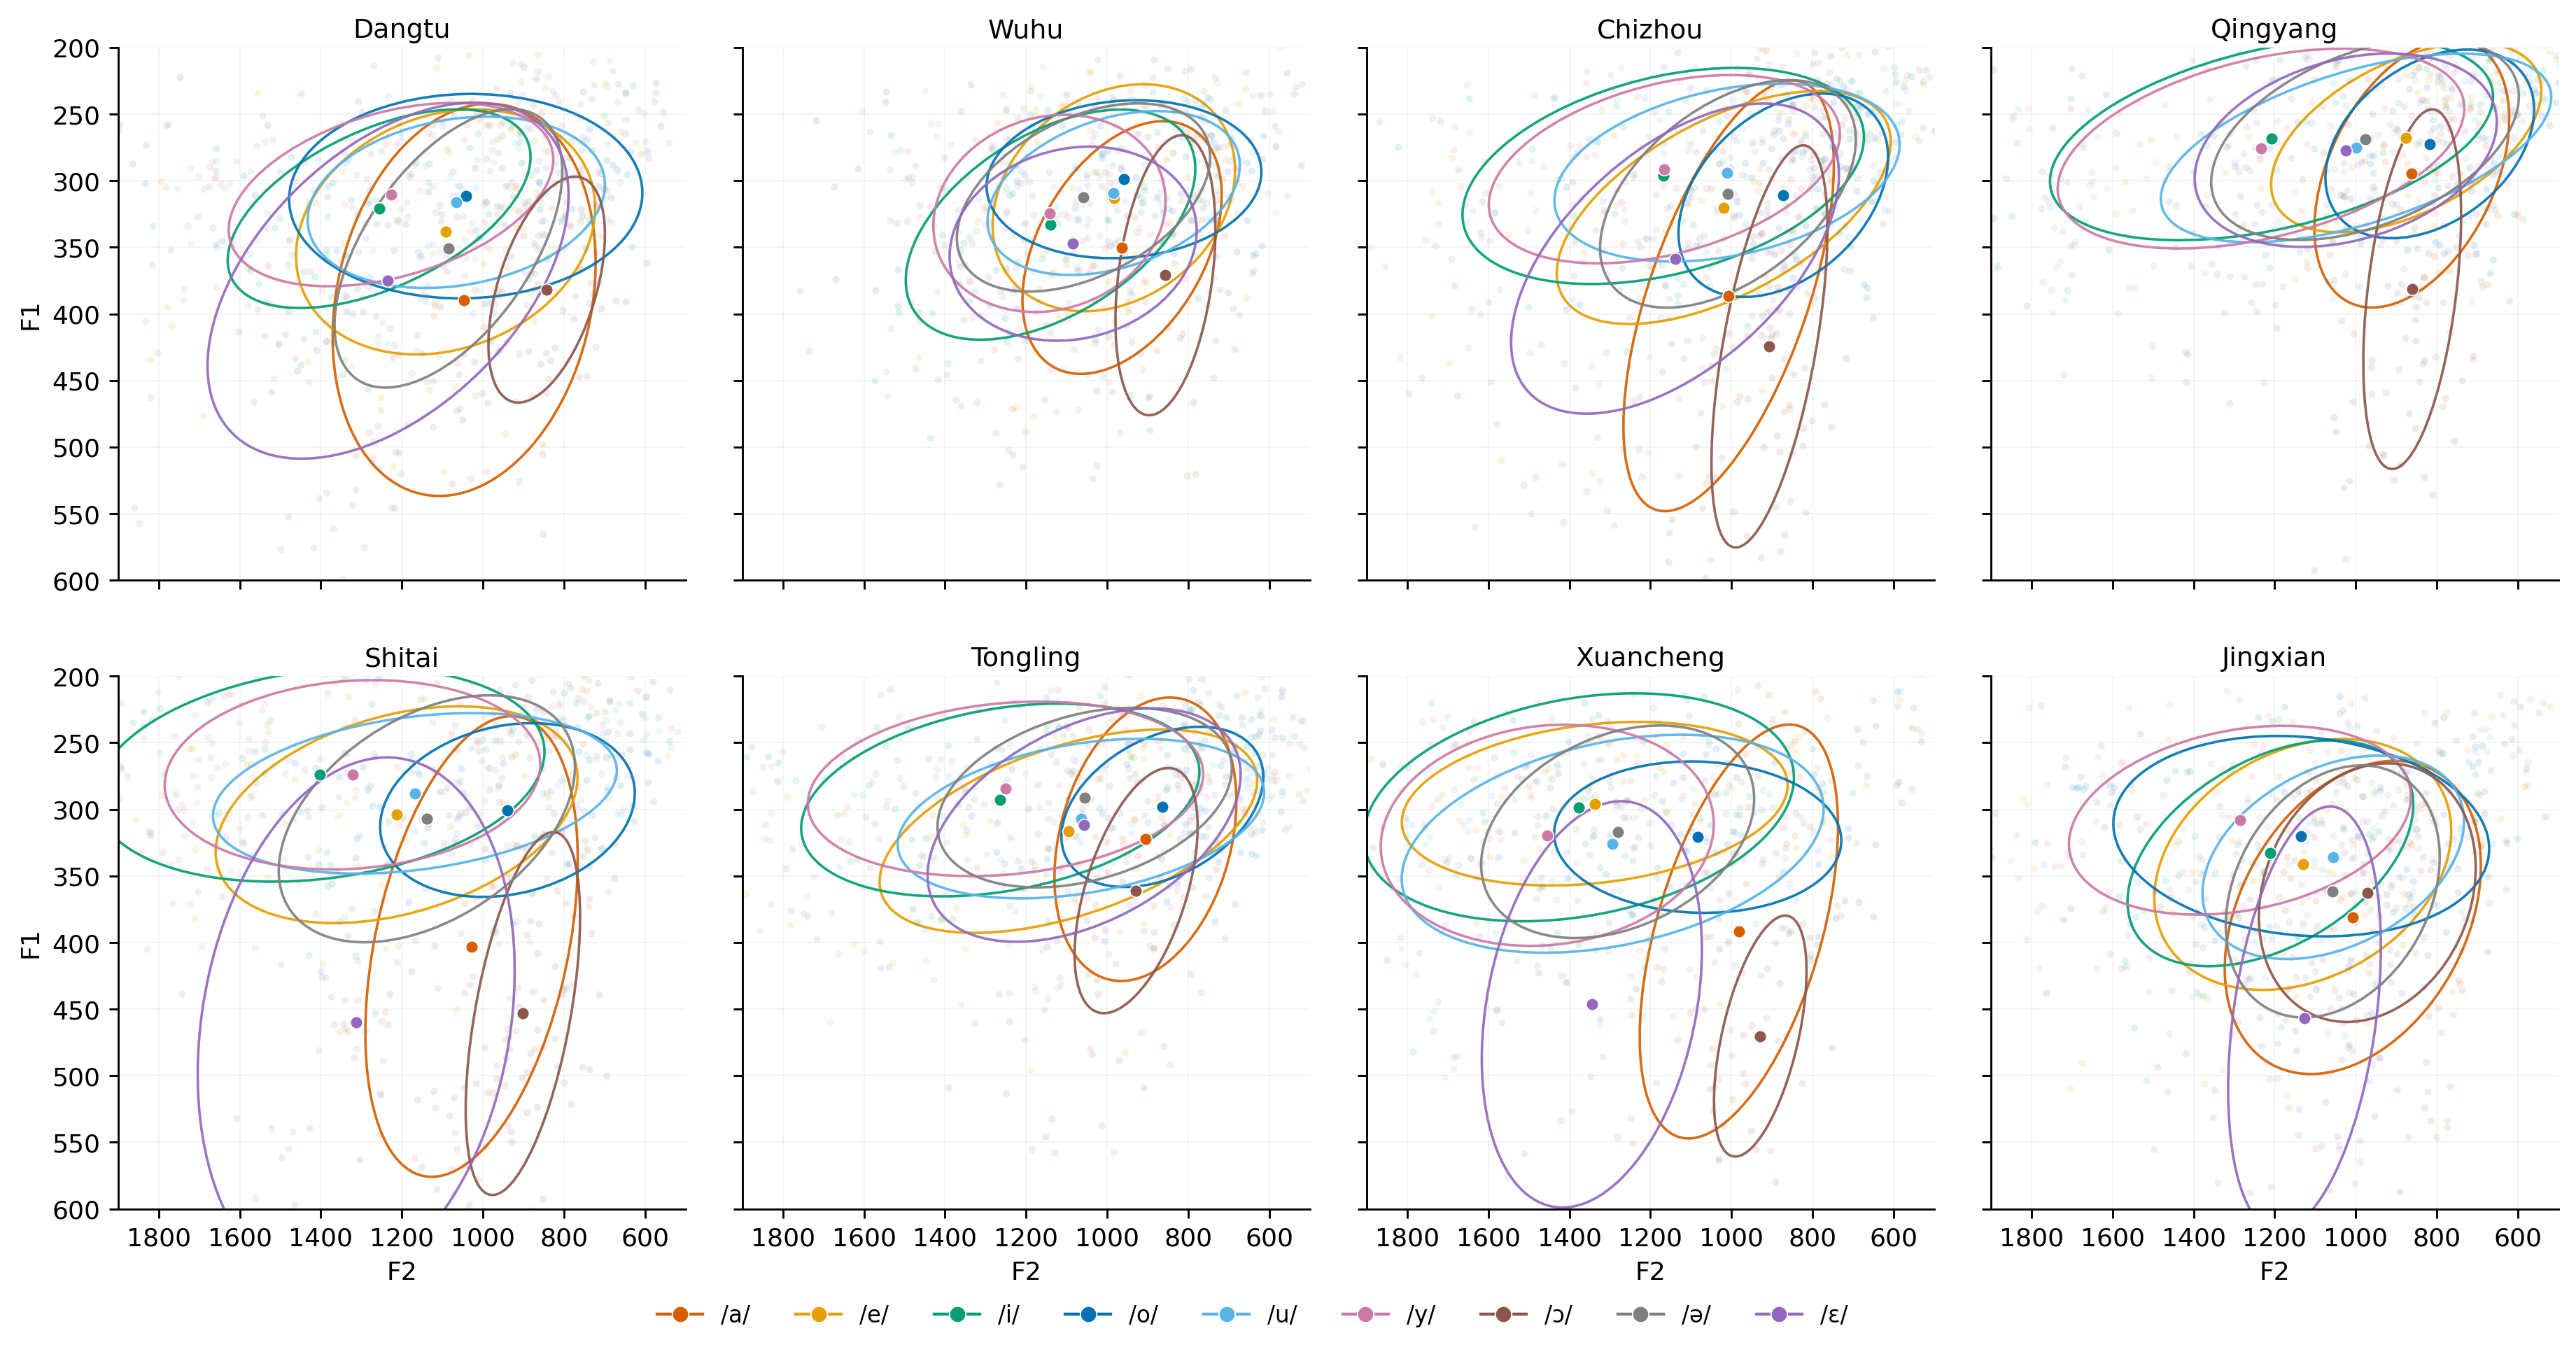


Saved figure files:
png: /home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/fig_8regions_9vowels.png


In [4]:
# ============================================================
# Wu vowel-space plotting script
# Compatible with older Python versions used by Jupyter
#
# Functions:
# 1. Read and clean all 14 regions.
# 2. Save metrics for all 14 regions.
# 3. Save metrics for 14 regions x 9 vowels.
# 4. Plot only the selected 8 regions.
# 5. Keep scatter points, ellipses, and center points.
# 6. Use a color legend for 9 vowels.
# 7. No overall title; subplot titles show region names only.
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse


# ============================================================
# 0. Paths and configuration
# ============================================================

# 保留你修改后的数据路径
CSV_PATH = Path(
    r"/home/ustc1958/lxy/graph/tone/complete_package0614/"
    r"wu_vowel_segments.f1f2_per_audio.csv"
)

# 保留你修改后的保存路径
OUT_DIR = Path(
    r"/home/ustc1958/lxy/graph/tone/complete_package0614/"
    r"pc_dlcmnet_figures_hybrid"
)

OUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 图中只显示这 8 个地区
# 修改这里即可更换图中的 8 个地区
# ------------------------------------------------------------
PLOT_REGION_CODES = [
    "01当涂",
    "02芜湖",
    "03池州",
    "04青阳",
    "05石台",
    "06铜陵",
    "07宣城",
    "08泾县",
]


# 不显示整张图的总标题
SHOW_SUPTITLE = False

# 子图标题只显示地区名，不显示 N
SHOW_N_IN_TITLE = False

# 每个“地区—元音”最多绘制多少个散点
# 只影响图上显示的点数，不影响椭圆、中心点和统计指标
MAX_POINTS_PER_CLUSTER = 70

# 是否保存不同格式
SAVE_PNG = True
SAVE_PDF = True
SAVE_SVG = True


# 9 个元音
VOWELS = [
    "a",
    "e",
    "i",
    "o",
    "u",
    "y",
    "ɔ",
    "ə",
    "ɛ",
]


# 全部 14 个地区
# 统计指标始终使用这里的全部 14 个地区
REGIONS_14 = [
    ("01当涂", "Dangtu"),
    ("02芜湖", "Wuhu"),
    ("03池州", "Chizhou"),
    ("04青阳", "Qingyang"),
    ("05石台", "Shitai"),
    ("06铜陵", "Tongling"),
    ("07宣城", "Xuancheng"),
    ("08泾县", "Jingxian"),
    ("09繁昌", "Fanchang"),
    ("10南陵", "Nanling"),
    ("11黄山", "Huangshan"),
    ("12宁国", "Ningguo"),
    ("13高淳", "Gaochun"),
    ("14溧水", "Lishui"),
]

REGION_NAME_MAP = dict(REGIONS_14)


# 9 个元音的颜色
COLORS = {
    "a": "#D55E00",
    "e": "#E69F00",
    "i": "#009E73",
    "o": "#0072B2",
    "u": "#56B4E9",
    "y": "#CC79A7",
    "ɔ": "#8C564B",
    "ə": "#7F7F7F",
    "ɛ": "#9467BD",
}


# 矢量图中的文字保持可编辑
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


# ============================================================
# 1. Helper functions
# ============================================================

def corrected_region_from_path(wav_path, region_codes):
    """
    根据 wav_path 中的一级地区目录恢复真实地区标签。

    参数
    ----
    wav_path:
        音频文件路径。
    region_codes:
        允许匹配的地区代码列表。

    返回
    ----
    成功匹配时返回地区代码，否则返回 np.nan。
    """
    path_parts = str(wav_path).replace("\\", "/").split("/")
    matches = [
        region_code
        for region_code in region_codes
        if region_code in path_parts
    ]

    if len(matches) == 1:
        return matches[0]

    return np.nan


def robust_filter_region_vowel(df):
    """
    在每个“地区—元音”组内分别对 F1 和 F2 做 IQR 异常值过滤。
    """
    keep_indices = []

    grouped = df.groupby(
        ["paper_region_fixed", "vowel"],
        sort=False,
    )

    for _, group in grouped:
        # 样本过少时不进行 IQR 删除
        if len(group) < 10:
            keep_indices.extend(group.index.tolist())
            continue

        q1_f1 = group["f1_mean_hz"].quantile(0.25)
        q3_f1 = group["f1_mean_hz"].quantile(0.75)
        q1_f2 = group["f2_mean_hz"].quantile(0.25)
        q3_f2 = group["f2_mean_hz"].quantile(0.75)

        iqr_f1 = q3_f1 - q1_f1
        iqr_f2 = q3_f2 - q1_f2

        f1_lower = q1_f1 - 1.5 * iqr_f1
        f1_upper = q3_f1 + 1.5 * iqr_f1
        f2_lower = q1_f2 - 1.5 * iqr_f2
        f2_upper = q3_f2 + 1.5 * iqr_f2

        mask = (
            group["f1_mean_hz"].between(f1_lower, f1_upper)
            & group["f2_mean_hz"].between(f2_lower, f2_upper)
        )

        keep_indices.extend(group.loc[mask].index.tolist())

    keep_indices = sorted(set(keep_indices))
    return df.loc[keep_indices].copy()


def load_and_clean_data(csv_path):
    """
    读取全部 14 个地区的数据并清洗 F1/F2。
    """
    if not csv_path.exists():
        raise FileNotFoundError(
            "CSV file not found: {}".format(csv_path)
        )

    df = pd.read_csv(csv_path)

    required_columns = {
        "wav_path",
        "vowel",
        "f1_mean_hz",
        "f2_mean_hz",
    }

    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        raise ValueError(
            "Missing required columns: {}".format(
                sorted(missing_columns)
            )
        )

    all_region_codes = [
        region_code
        for region_code, _ in REGIONS_14
    ]

    # 根据路径恢复 14 个真实地区标签
    df["paper_region_fixed"] = df["wav_path"].apply(
        lambda wav_path: corrected_region_from_path(
            wav_path,
            all_region_codes,
        )
    )

    # 只保留 14 个地区和 9 个元音
    df = df[
        df["paper_region_fixed"].isin(all_region_codes)
    ].copy()

    df = df[
        df["vowel"].isin(VOWELS)
    ].copy()

    # 转换成数值
    df["f1_mean_hz"] = pd.to_numeric(
        df["f1_mean_hz"],
        errors="coerce",
    )

    df["f2_mean_hz"] = pd.to_numeric(
        df["f2_mean_hz"],
        errors="coerce",
    )

    # 删除缺失值
    df = df.dropna(
        subset=["f1_mean_hz", "f2_mean_hz"]
    )

    # 基本声学合理范围
    valid_mask = (
        df["f1_mean_hz"].between(150, 1200)
        & df["f2_mean_hz"].between(500, 3500)
        & (df["f2_mean_hz"] > df["f1_mean_hz"])
    )

    df = df.loc[valid_mask].copy()

    # 对各地区、各元音分别做稳健异常值过滤
    df = robust_filter_region_vowel(df)

    return df


# ============================================================
# 2. Metrics for all 14 regions
# ============================================================

def safe_group_value(group, column_name, operation):
    """
    对可能不存在的列或空分组安全地计算统计量。
    """
    if group.empty:
        return np.nan

    if column_name not in group.columns:
        return np.nan

    series = group[column_name]

    if operation == "nunique":
        return series.nunique()

    if operation == "mean":
        return series.mean()

    if operation == "std":
        return series.std(ddof=1)

    if operation == "median":
        return series.median()

    raise ValueError(
        "Unsupported operation: {}".format(operation)
    )


def compute_region_summary(df):
    """
    生成全部 14 个地区的整体指标。

    即使某个地区没有有效样本，也会保留该地区的一行，
    以保证输出表始终包含 14 个地区。
    """
    rows = []

    for region_code, region_en in REGIONS_14:
        group = df[
            df["paper_region_fixed"] == region_code
        ]

        row = {
            "paper_region": region_code,
            "region_en": region_en,
            "n_segments": int(len(group)),
            "n_speakers": safe_group_value(
                group,
                "speaker_id",
                "nunique",
            ),
            "n_sites": safe_group_value(
                group,
                "site",
                "nunique",
            ),
            "f1_mean_hz": safe_group_value(
                group,
                "f1_mean_hz",
                "mean",
            ),
            "f1_std_hz": safe_group_value(
                group,
                "f1_mean_hz",
                "std",
            ),
            "f1_median_hz": safe_group_value(
                group,
                "f1_mean_hz",
                "median",
            ),
            "f2_mean_hz": safe_group_value(
                group,
                "f2_mean_hz",
                "mean",
            ),
            "f2_std_hz": safe_group_value(
                group,
                "f2_mean_hz",
                "std",
            ),
            "f2_median_hz": safe_group_value(
                group,
                "f2_mean_hz",
                "median",
            ),
        }

        rows.append(row)

    return pd.DataFrame(rows)


def compute_region_vowel_summary(df):
    """
    生成 14 个地区 × 9 个元音的指标。

    输出始终包含 14 × 9 = 126 行。
    没有有效样本的组合保留为 n_segments=0，其他指标为 NaN。
    """
    rows = []

    for region_code, region_en in REGIONS_14:
        for vowel in VOWELS:
            group = df[
                (df["paper_region_fixed"] == region_code)
                & (df["vowel"] == vowel)
            ]

            row = {
                "paper_region": region_code,
                "region_en": region_en,
                "vowel": vowel,
                "n_segments": int(len(group)),
                "n_speakers": safe_group_value(
                    group,
                    "speaker_id",
                    "nunique",
                ),
                "n_sites": safe_group_value(
                    group,
                    "site",
                    "nunique",
                ),
                "f1_mean_hz": safe_group_value(
                    group,
                    "f1_mean_hz",
                    "mean",
                ),
                "f1_std_hz": safe_group_value(
                    group,
                    "f1_mean_hz",
                    "std",
                ),
                "f1_median_hz": safe_group_value(
                    group,
                    "f1_mean_hz",
                    "median",
                ),
                "f2_mean_hz": safe_group_value(
                    group,
                    "f2_mean_hz",
                    "mean",
                ),
                "f2_std_hz": safe_group_value(
                    group,
                    "f2_mean_hz",
                    "std",
                ),
                "f2_median_hz": safe_group_value(
                    group,
                    "f2_mean_hz",
                    "median",
                ),
            }

            rows.append(row)

    return pd.DataFrame(rows)


# ============================================================
# 3. Plotting
# ============================================================

def add_confidence_ellipse(
    ax,
    x,
    y,
    color,
    scale=1.20,
):
    """
    根据 F2/F1 协方差绘制椭圆。
    """
    if len(x) < 8:
        return

    covariance = np.cov(x, y)

    if not np.all(np.isfinite(covariance)):
        return

    eigenvalues, eigenvectors = np.linalg.eigh(covariance)

    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    angle = np.degrees(
        np.arctan2(
            eigenvectors[1, 0],
            eigenvectors[0, 0],
        )
    )

    width, height = (
        2
        * scale
        * np.sqrt(np.maximum(eigenvalues, 1e-6))
    )

    ellipse = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=angle,
        fill=False,
        edgecolor=color,
        linewidth=1.0,
        alpha=0.92,
    )

    ax.add_patch(ellipse)


def validate_plot_regions():
    """
    检查图中选择的 8 个地区是否合法。
    """
    unknown_codes = [
        region_code
        for region_code in PLOT_REGION_CODES
        if region_code not in REGION_NAME_MAP
    ]

    if unknown_codes:
        raise ValueError(
            "Unknown region codes in PLOT_REGION_CODES: {}".format(
                unknown_codes
            )
        )

    if len(PLOT_REGION_CODES) != 8:
        raise ValueError(
            "PLOT_REGION_CODES must contain exactly 8 regions."
        )

    if len(set(PLOT_REGION_CODES)) != 8:
        raise ValueError(
            "PLOT_REGION_CODES contains duplicated regions."
        )


def get_plot_region_list():
    """
    按 PLOT_REGION_CODES 中给出的顺序返回地区信息。
    """
    validate_plot_regions()

    plot_region_list = []

    for region_code in PLOT_REGION_CODES:
        plot_region_list.append(
            (
                region_code,
                REGION_NAME_MAP[region_code],
            )
        )

    return plot_region_list


def plot_8_regions(df_all):
    """
    只绘制 PLOT_REGION_CODES 指定的 8 个地区。

    统计指标仍然来自全部 14 个地区的数据。
    """
    plot_region_list = get_plot_region_list()

    plot_region_codes = [
        region_code
        for region_code, _ in plot_region_list
    ]

    df_plot = df_all[
        df_all["paper_region_fixed"].isin(plot_region_codes)
    ].copy()

    if df_plot.empty:
        raise ValueError(
            "No valid data found for the selected 8 regions."
        )

    fig, axes = plt.subplots(
        2,
        4,
        figsize=(14.5, 7.6),
        dpi=260,
        sharex=True,
        sharey=True,
    )

    axes = np.asarray(axes).reshape(-1)

    # 8 个子图统一使用相同的坐标范围
    f2_left = min(
        3200,
        np.ceil(
            df_plot["f2_mean_hz"].quantile(0.98) / 100
        ) * 100,
    )

    f2_right = max(
        500,
        np.floor(
            df_plot["f2_mean_hz"].quantile(0.02) / 100
        ) * 100,
    )

    f1_bottom = min(
        1000,
        np.ceil(
            df_plot["f1_mean_hz"].quantile(0.98) / 50
        ) * 50,
    )

    f1_top = max(
        200,
        np.floor(
            df_plot["f1_mean_hz"].quantile(0.02) / 50
        ) * 50,
    )

    for subplot_index, region_info in enumerate(plot_region_list):
        region_code, region_en = region_info
        ax = axes[subplot_index]

        region_df = df_plot[
            df_plot["paper_region_fixed"] == region_code
        ]

        for vowel in VOWELS:
            group = region_df.loc[
                region_df["vowel"] == vowel,
                ["f1_mean_hz", "f2_mean_hz"],
            ]

            if group.empty:
                continue

            # 散点仅做可视化采样
            # 不影响椭圆、中心点和 CSV 指标
            if len(group) > MAX_POINTS_PER_CLUSTER:
                plot_group = group.sample(
                    n=MAX_POINTS_PER_CLUSTER,
                    random_state=42,
                )
            else:
                plot_group = group

            ax.scatter(
                plot_group["f2_mean_hz"],
                plot_group["f1_mean_hz"],
                s=8,
                alpha=0.12,
                color=COLORS[vowel],
                linewidths=0,
                zorder=1,
            )

            # 使用全部有效样本计算椭圆
            add_confidence_ellipse(
                ax=ax,
                x=group["f2_mean_hz"].to_numpy(),
                y=group["f1_mean_hz"].to_numpy(),
                color=COLORS[vowel],
                scale=1.20,
            )

            # 元音中心点
            ax.scatter(
                group["f2_mean_hz"].mean(),
                group["f1_mean_hz"].mean(),
                s=24,
                color=COLORS[vowel],
                edgecolors="white",
                linewidths=0.45,
                zorder=3,
            )

        # 子图只显示地区名
        if SHOW_N_IN_TITLE:
            title_text = "{}\nN={:,}".format(
                region_en,
                len(region_df),
            )
        else:
            title_text = region_en

        ax.set_title(
            title_text,
            fontsize=10.5,
            pad=4,
        )

        # F2 与 F1 都倒置，符合常用元音空间展示方式
        ax.set_xlim(f2_left, f2_right)
        ax.set_ylim(f1_bottom, f1_top)

        ax.grid(
            alpha=0.14,
            linewidth=0.5,
        )

        if subplot_index % 4 == 0:
            ax.set_ylabel(
                "F1",
                fontsize=10,
            )

        if subplot_index >= 4:
            ax.set_xlabel(
                "F2",
                fontsize=10,
            )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # 底部颜色图例：9 个元音
    legend_handles = []

    for vowel in VOWELS:
        legend_handle = Line2D(
            [0],
            [0],
            color=COLORS[vowel],
            marker="o",
            linestyle="-",
            linewidth=1.2,
            markersize=6.5,
            markerfacecolor=COLORS[vowel],
            markeredgecolor="white",
            markeredgewidth=0.5,
            label="/{}/".format(vowel),
        )

        legend_handles.append(legend_handle)

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=9,
        frameon=False,
        fontsize=9,
        bbox_to_anchor=(0.5, 0.02),
    )

    # 默认不显示总标题
    if SHOW_SUPTITLE:
        fig.suptitle(
            "Cross-Regional Wu Vowel Space",
            fontsize=15,
            fontweight="bold",
            y=0.98,
        )

    fig.subplots_adjust(
        left=0.07,
        right=0.995,
        top=0.96 if not SHOW_SUPTITLE else 0.92,
        bottom=0.12,
        wspace=0.10,
        hspace=0.18,
    )

    output_paths = {
        "png": OUT_DIR / "fig_8regions_9vowels.png",
    }

    if SAVE_PNG:
        fig.savefig(
            output_paths["png"],
            dpi=300,
            bbox_inches="tight",
        )


    # 在 Jupyter 中直接显示
    plt.show()
    plt.close(fig)

    # 不使用 Path | None，兼容旧版 Python
    saved_paths = {}

    if SAVE_PNG:
        saved_paths["png"] = output_paths["png"]



    return saved_paths


# ============================================================
# 4. Main
# ============================================================

def main():
    """
    先用全部 14 个地区计算指标，
    再只使用指定的 8 个地区绘图。
    """
    print("CSV path:")
    print(CSV_PATH)

    print("\nOutput directory:")
    print(OUT_DIR)

    # --------------------------------------------------------
    # A. 加载全部 14 个地区
    # --------------------------------------------------------
    df_all = load_and_clean_data(CSV_PATH)

    print(
        "\nCleaned rows from all 14 regions: {:,}".format(
            len(df_all)
        )
    )

    # --------------------------------------------------------
    # B. 保存全部 14 个地区的整体指标
    # --------------------------------------------------------
    region_summary = compute_region_summary(df_all)

    region_summary_path = (
        OUT_DIR / "region_summary_14regions.csv"
    )

    region_summary.to_csv(
        region_summary_path,
        index=False,
        encoding="utf-8-sig",
    )

    # --------------------------------------------------------
    # C. 保存 14 地区 × 9 元音指标
    # --------------------------------------------------------
    region_vowel_summary = compute_region_vowel_summary(df_all)

    region_vowel_summary_path = (
        OUT_DIR
        / "region_vowel_summary_14regions_9vowels.csv"
    )

    region_vowel_summary.to_csv(
        region_vowel_summary_path,
        index=False,
        encoding="utf-8-sig",
    )

    print("\nSaved metric files:")
    print(region_summary_path)
    print(region_vowel_summary_path)

    print(
        "Region summary rows: {}".format(
            len(region_summary)
        )
    )

    print(
        "Region-vowel summary rows: {}".format(
            len(region_vowel_summary)
        )
    )

    # --------------------------------------------------------
    # D. 只画配置中的 8 个地区
    # --------------------------------------------------------
    print("\nRegions used in the figure:")

    for region_code in PLOT_REGION_CODES:
        print(
            "{}  {}".format(
                region_code,
                REGION_NAME_MAP[region_code],
            )
        )

    figure_paths = plot_8_regions(df_all)

    print("\nSaved figure files:")

    for file_type, file_path in figure_paths.items():
        print(
            "{}: {}".format(
                file_type,
                file_path,
            )
        )


# 在 .py 和 ipynb 中都可以直接运行
main()

CSV path:
/home/ustc1958/lxy/graph/tone/complete_package0614/wu_vowel_segments.f1f2_per_audio.csv

Output directory:
/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid

Cleaned rows from all 14 regions: 43,905

Saved metric files:
/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/region_summary_14regions.csv
/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/region_vowel_summary_14regions_9vowels.csv
Region summary rows: 14
Region-vowel summary rows: 126

Regions used in the figure:
01当涂  Dangtu
02芜湖  Wuhu
03池州  Chizhou
04青阳  Qingyang
05石台  Shitai
06铜陵  Tongling
07宣城  Xuancheng
08泾县  Jingxian


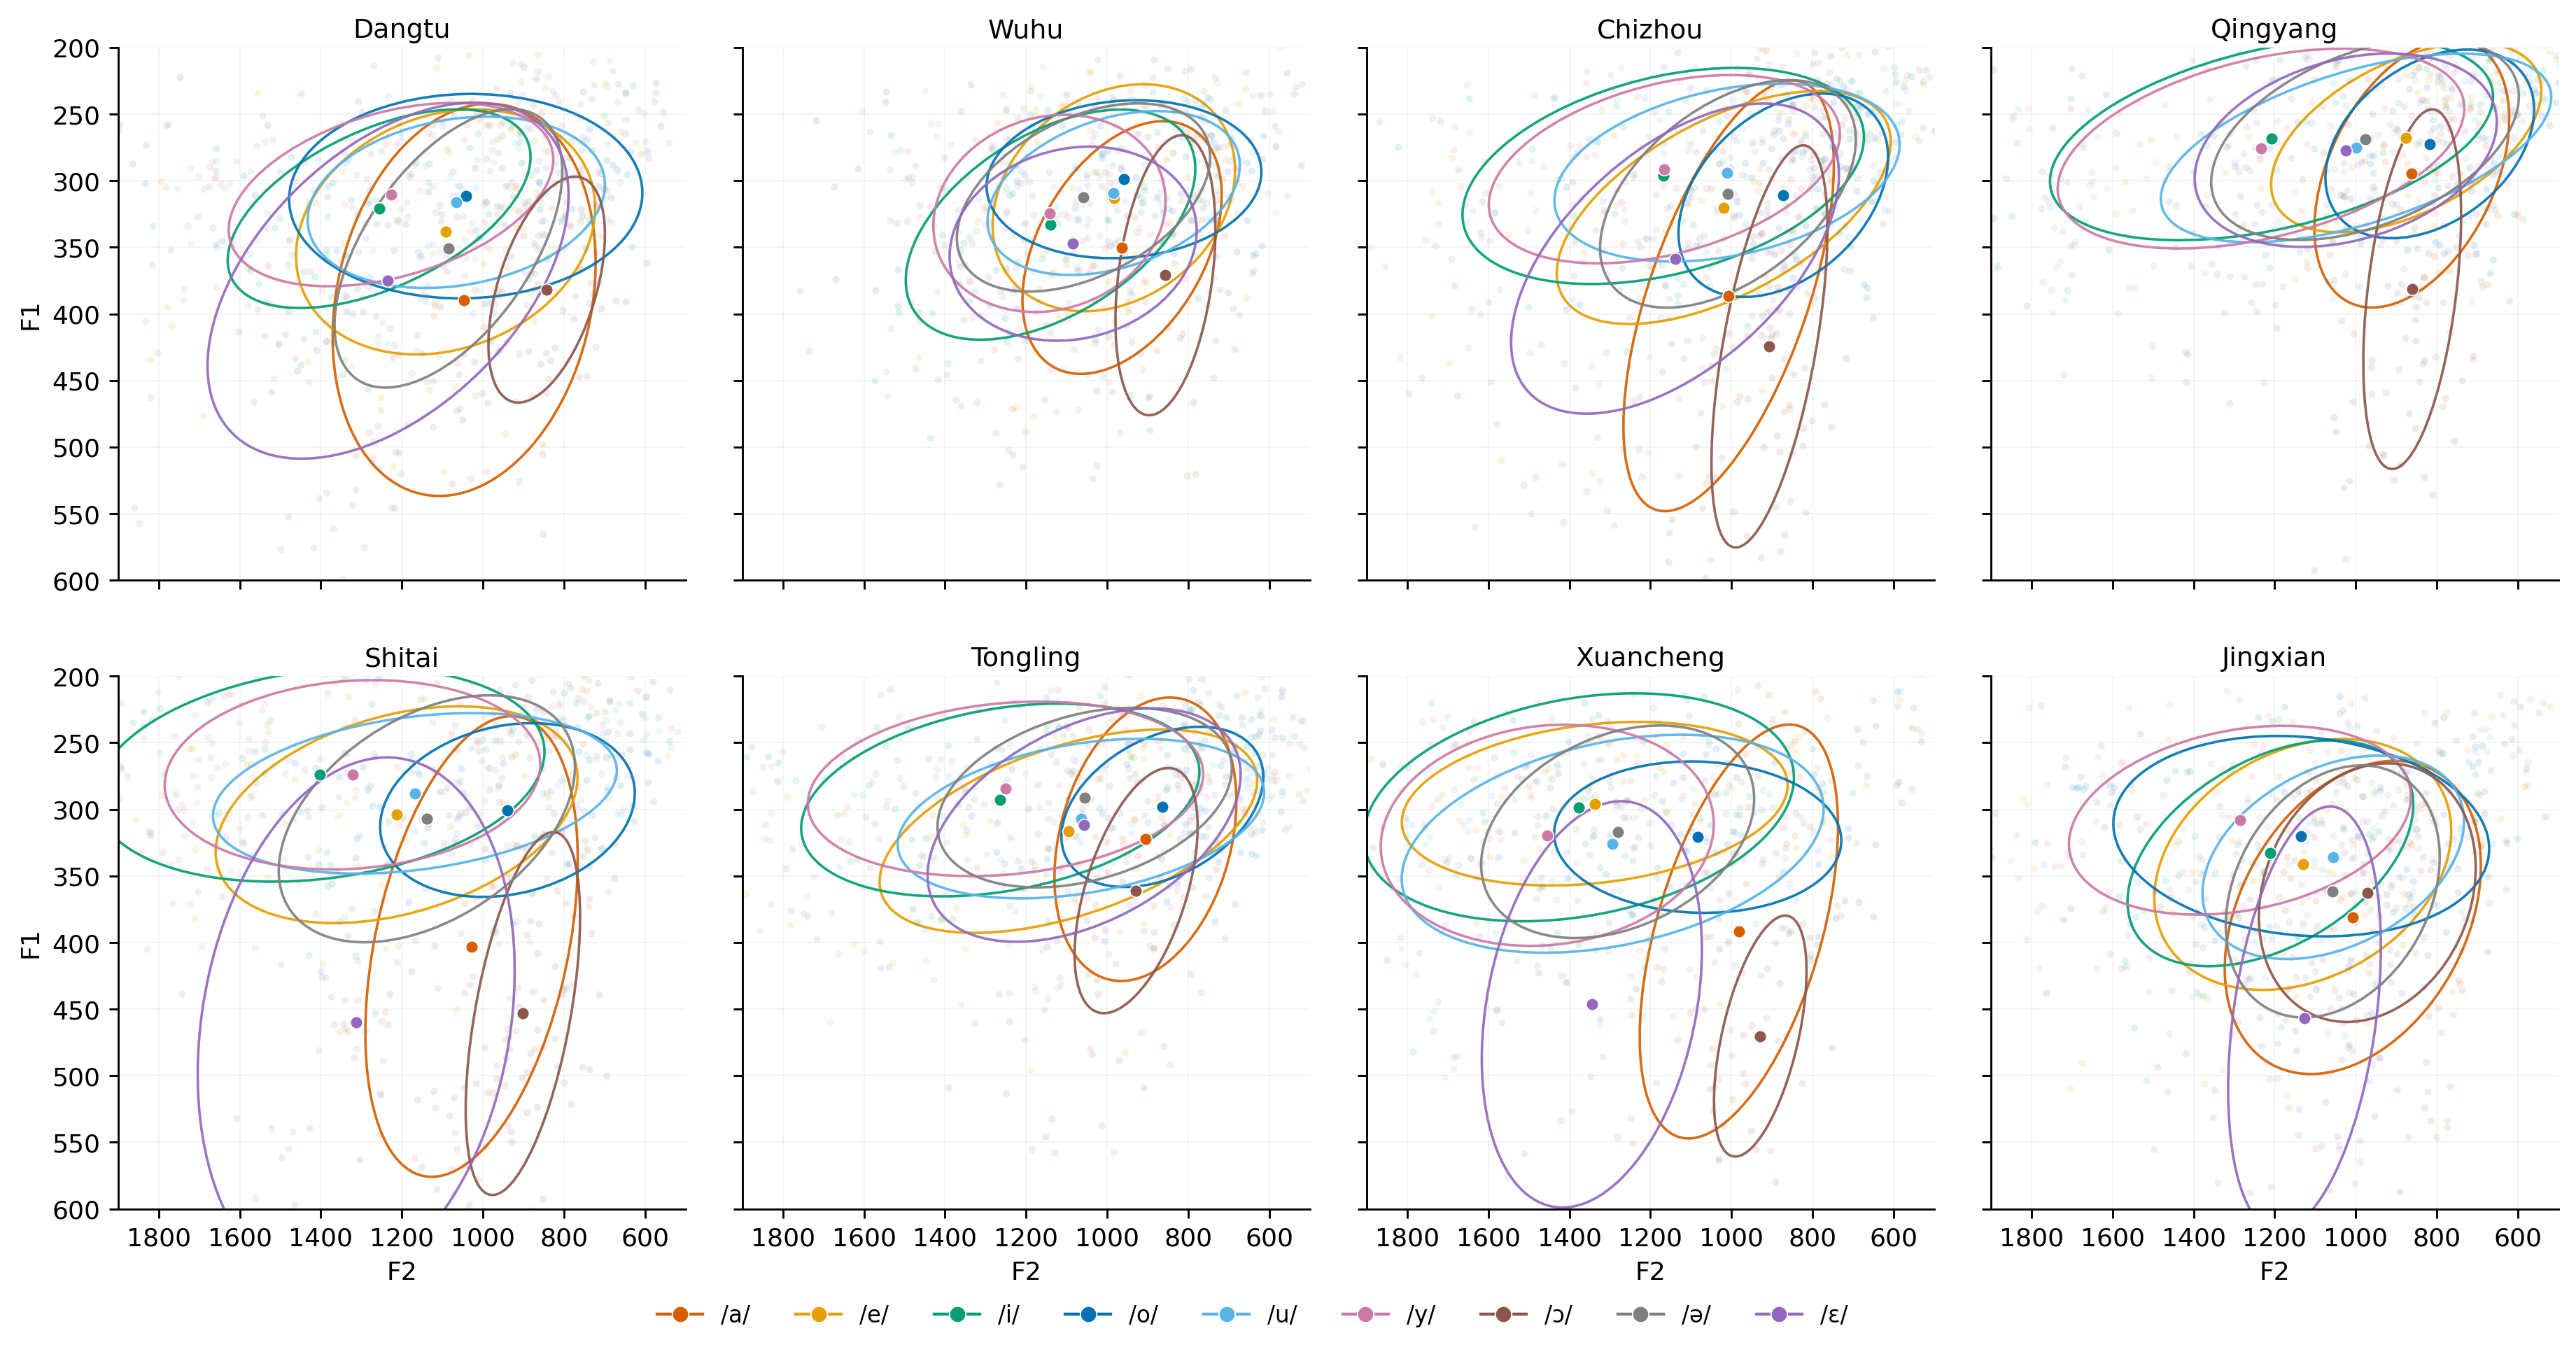


Saved figure files:
png: /home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/fig_8regions_9vowels.png


In [6]:
# ============================================================
# Wu vowel-space plotting script
# Compatible with older Python versions used by Jupyter
#
# Functions:
# 1. Read and clean all 14 regions.
# 2. Save metrics for all 14 regions.
# 3. Save metrics for 14 regions x 9 vowels.
# 4. Plot only the selected 8 regions.
# 5. Keep scatter points, ellipses, and center points.
# 6. Use a color legend for 9 vowels.
# 7. No overall title; subplot titles show region names only.
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse


# ============================================================
# 0. Paths and configuration
# ============================================================

# 保留你修改后的数据路径
CSV_PATH = Path(
    r"/home/ustc1958/lxy/graph/tone/complete_package0614/"
    r"wu_vowel_segments.f1f2_per_audio.csv"
)

# 保留你修改后的保存路径
OUT_DIR = Path(
    r"/home/ustc1958/lxy/graph/tone/complete_package0614/"
    r"pc_dlcmnet_figures_hybrid"
)

OUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 图中只显示这 8 个地区
# 修改这里即可更换图中的 8 个地区
# ------------------------------------------------------------
PLOT_REGION_CODES = [
    "01当涂",
    "02芜湖",
    "03池州",
    "04青阳",
    "05石台",
    "06铜陵",
    "07宣城",
    "08泾县",
]


# 不显示整张图的总标题
SHOW_SUPTITLE = False

# 子图标题只显示地区名，不显示 N
SHOW_N_IN_TITLE = False

# 每个“地区—元音”最多绘制多少个散点
# 只影响图上显示的点数，不影响椭圆、中心点和统计指标
MAX_POINTS_PER_CLUSTER = 70

# 是否保存不同格式
SAVE_PNG = True
SAVE_PDF = True
SAVE_SVG = True


# 9 个元音
VOWELS = [
    "a",
    "e",
    "i",
    "o",
    "u",
    "y",
    "ɔ",
    "ə",
    "ɛ",
]


# 全部 14 个地区
# 统计指标始终使用这里的全部 14 个地区
REGIONS_14 = [
    ("01当涂", "Dangtu"),
    ("02芜湖", "Wuhu"),
    ("03池州", "Chizhou"),
    ("04青阳", "Qingyang"),
    ("05石台", "Shitai"),
    ("06铜陵", "Tongling"),
    ("07宣城", "Xuancheng"),
    ("08泾县", "Jingxian"),
    ("09繁昌", "Fanchang"),
    ("10南陵", "Nanling"),
    ("11黄山", "Huangshan"),
    ("12宁国", "Ningguo"),
    ("13高淳", "Gaochun"),
    ("14溧水", "Lishui"),
]

REGION_NAME_MAP = dict(REGIONS_14)


# 9 个元音的颜色
COLORS = {
    "a": "#D55E00",
    "e": "#E69F00",
    "i": "#009E73",
    "o": "#0072B2",
    "u": "#56B4E9",
    "y": "#CC79A7",
    "ɔ": "#8C564B",
    "ə": "#7F7F7F",
    "ɛ": "#9467BD",
}


# 矢量图中的文字保持可编辑
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


# ============================================================
# 1. Helper functions
# ============================================================

def corrected_region_from_path(wav_path, region_codes):
    """
    根据 wav_path 中的一级地区目录恢复真实地区标签。

    参数
    ----
    wav_path:
        音频文件路径。
    region_codes:
        允许匹配的地区代码列表。

    返回
    ----
    成功匹配时返回地区代码，否则返回 np.nan。
    """
    path_parts = str(wav_path).replace("\\", "/").split("/")
    matches = [
        region_code
        for region_code in region_codes
        if region_code in path_parts
    ]

    if len(matches) == 1:
        return matches[0]

    return np.nan


def robust_filter_region_vowel(df):
    """
    在每个“地区—元音”组内分别对 F1 和 F2 做 IQR 异常值过滤。
    """
    keep_indices = []

    grouped = df.groupby(
        ["paper_region_fixed", "vowel"],
        sort=False,
    )

    for _, group in grouped:
        # 样本过少时不进行 IQR 删除
        if len(group) < 10:
            keep_indices.extend(group.index.tolist())
            continue

        q1_f1 = group["f1_mean_hz"].quantile(0.25)
        q3_f1 = group["f1_mean_hz"].quantile(0.75)
        q1_f2 = group["f2_mean_hz"].quantile(0.25)
        q3_f2 = group["f2_mean_hz"].quantile(0.75)

        iqr_f1 = q3_f1 - q1_f1
        iqr_f2 = q3_f2 - q1_f2

        f1_lower = q1_f1 - 1.5 * iqr_f1
        f1_upper = q3_f1 + 1.5 * iqr_f1
        f2_lower = q1_f2 - 1.5 * iqr_f2
        f2_upper = q3_f2 + 1.5 * iqr_f2

        mask = (
            group["f1_mean_hz"].between(f1_lower, f1_upper)
            & group["f2_mean_hz"].between(f2_lower, f2_upper)
        )

        keep_indices.extend(group.loc[mask].index.tolist())

    keep_indices = sorted(set(keep_indices))
    return df.loc[keep_indices].copy()


def load_and_clean_data(csv_path):
    """
    读取全部 14 个地区的数据并清洗 F1/F2。
    """
    if not csv_path.exists():
        raise FileNotFoundError(
            "CSV file not found: {}".format(csv_path)
        )

    df = pd.read_csv(csv_path)

    required_columns = {
        "wav_path",
        "vowel",
        "f1_mean_hz",
        "f2_mean_hz",
    }

    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        raise ValueError(
            "Missing required columns: {}".format(
                sorted(missing_columns)
            )
        )

    all_region_codes = [
        region_code
        for region_code, _ in REGIONS_14
    ]

    # 根据路径恢复 14 个真实地区标签
    df["paper_region_fixed"] = df["wav_path"].apply(
        lambda wav_path: corrected_region_from_path(
            wav_path,
            all_region_codes,
        )
    )

    # 只保留 14 个地区和 9 个元音
    df = df[
        df["paper_region_fixed"].isin(all_region_codes)
    ].copy()

    df = df[
        df["vowel"].isin(VOWELS)
    ].copy()

    # 转换成数值
    df["f1_mean_hz"] = pd.to_numeric(
        df["f1_mean_hz"],
        errors="coerce",
    )

    df["f2_mean_hz"] = pd.to_numeric(
        df["f2_mean_hz"],
        errors="coerce",
    )

    # 删除缺失值
    df = df.dropna(
        subset=["f1_mean_hz", "f2_mean_hz"]
    )

    # 基本声学合理范围
    valid_mask = (
        df["f1_mean_hz"].between(150, 1200)
        & df["f2_mean_hz"].between(500, 3500)
        & (df["f2_mean_hz"] > df["f1_mean_hz"])
    )

    df = df.loc[valid_mask].copy()

    # 对各地区、各元音分别做稳健异常值过滤
    df = robust_filter_region_vowel(df)

    return df


# ============================================================
# 2. Metrics for all 14 regions
# ============================================================

def safe_group_value(group, column_name, operation):
    """
    对可能不存在的列或空分组安全地计算统计量。
    """
    if group.empty:
        return np.nan

    if column_name not in group.columns:
        return np.nan

    series = group[column_name]

    if operation == "nunique":
        return series.nunique()

    if operation == "mean":
        return series.mean()

    if operation == "std":
        return series.std(ddof=1)

    if operation == "median":
        return series.median()

    raise ValueError(
        "Unsupported operation: {}".format(operation)
    )


def compute_region_summary(df):
    """
    生成全部 14 个地区的整体指标。

    即使某个地区没有有效样本，也会保留该地区的一行，
    以保证输出表始终包含 14 个地区。
    """
    rows = []

    for region_code, region_en in REGIONS_14:
        group = df[
            df["paper_region_fixed"] == region_code
        ]

        row = {
            "paper_region": region_code,
            "region_en": region_en,
            "n_segments": int(len(group)),
            "n_speakers": safe_group_value(
                group,
                "speaker_id",
                "nunique",
            ),
            "n_sites": safe_group_value(
                group,
                "site",
                "nunique",
            ),
            "f1_mean_hz": safe_group_value(
                group,
                "f1_mean_hz",
                "mean",
            ),
            "f1_std_hz": safe_group_value(
                group,
                "f1_mean_hz",
                "std",
            ),
            "f1_median_hz": safe_group_value(
                group,
                "f1_mean_hz",
                "median",
            ),
            "f2_mean_hz": safe_group_value(
                group,
                "f2_mean_hz",
                "mean",
            ),
            "f2_std_hz": safe_group_value(
                group,
                "f2_mean_hz",
                "std",
            ),
            "f2_median_hz": safe_group_value(
                group,
                "f2_mean_hz",
                "median",
            ),
        }

        rows.append(row)

    return pd.DataFrame(rows)


def compute_region_vowel_summary(df):
    """
    生成 14 个地区 × 9 个元音的指标。

    输出始终包含 14 × 9 = 126 行。
    没有有效样本的组合保留为 n_segments=0，其他指标为 NaN。
    """
    rows = []

    for region_code, region_en in REGIONS_14:
        for vowel in VOWELS:
            group = df[
                (df["paper_region_fixed"] == region_code)
                & (df["vowel"] == vowel)
            ]

            row = {
                "paper_region": region_code,
                "region_en": region_en,
                "vowel": vowel,
                "n_segments": int(len(group)),
                "n_speakers": safe_group_value(
                    group,
                    "speaker_id",
                    "nunique",
                ),
                "n_sites": safe_group_value(
                    group,
                    "site",
                    "nunique",
                ),
                "f1_mean_hz": safe_group_value(
                    group,
                    "f1_mean_hz",
                    "mean",
                ),
                "f1_std_hz": safe_group_value(
                    group,
                    "f1_mean_hz",
                    "std",
                ),
                "f1_median_hz": safe_group_value(
                    group,
                    "f1_mean_hz",
                    "median",
                ),
                "f2_mean_hz": safe_group_value(
                    group,
                    "f2_mean_hz",
                    "mean",
                ),
                "f2_std_hz": safe_group_value(
                    group,
                    "f2_mean_hz",
                    "std",
                ),
                "f2_median_hz": safe_group_value(
                    group,
                    "f2_mean_hz",
                    "median",
                ),
            }

            rows.append(row)

    return pd.DataFrame(rows)


# ============================================================
# 3. Plotting
# ============================================================

def add_confidence_ellipse(
    ax,
    x,
    y,
    color,
    scale=1.20,
):
    """
    根据 F2/F1 协方差绘制椭圆。
    """
    if len(x) < 8:
        return

    covariance = np.cov(x, y)

    if not np.all(np.isfinite(covariance)):
        return

    eigenvalues, eigenvectors = np.linalg.eigh(covariance)

    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    angle = np.degrees(
        np.arctan2(
            eigenvectors[1, 0],
            eigenvectors[0, 0],
        )
    )

    width, height = (
        2
        * scale
        * np.sqrt(np.maximum(eigenvalues, 1e-6))
    )

    ellipse = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=angle,
        fill=False,
        edgecolor=color,
        linewidth=1.0,
        alpha=0.92,
    )

    ax.add_patch(ellipse)


def validate_plot_regions():
    """
    检查图中选择的 8 个地区是否合法。
    """
    unknown_codes = [
        region_code
        for region_code in PLOT_REGION_CODES
        if region_code not in REGION_NAME_MAP
    ]

    if unknown_codes:
        raise ValueError(
            "Unknown region codes in PLOT_REGION_CODES: {}".format(
                unknown_codes
            )
        )

    if len(PLOT_REGION_CODES) != 8:
        raise ValueError(
            "PLOT_REGION_CODES must contain exactly 8 regions."
        )

    if len(set(PLOT_REGION_CODES)) != 8:
        raise ValueError(
            "PLOT_REGION_CODES contains duplicated regions."
        )


def get_plot_region_list():
    """
    按 PLOT_REGION_CODES 中给出的顺序返回地区信息。
    """
    validate_plot_regions()

    plot_region_list = []

    for region_code in PLOT_REGION_CODES:
        plot_region_list.append(
            (
                region_code,
                REGION_NAME_MAP[region_code],
            )
        )

    return plot_region_list


def plot_8_regions(df_all):
    """
    只绘制 PLOT_REGION_CODES 指定的 8 个地区。

    统计指标仍然来自全部 14 个地区的数据。
    """
    plot_region_list = get_plot_region_list()

    plot_region_codes = [
        region_code
        for region_code, _ in plot_region_list
    ]

    df_plot = df_all[
        df_all["paper_region_fixed"].isin(plot_region_codes)
    ].copy()

    if df_plot.empty:
        raise ValueError(
            "No valid data found for the selected 8 regions."
        )

    fig, axes = plt.subplots(
        2,
        4,
        figsize=(14.5, 7.6),
        dpi=260,
        sharex=True,
        sharey=True,
    )

    axes = np.asarray(axes).reshape(-1)

    # 8 个子图统一使用相同的坐标范围
    f2_left = min(
        3200,
        np.ceil(
            df_plot["f2_mean_hz"].quantile(0.98) / 100
        ) * 100,
    )

    f2_right = max(
        500,
        np.floor(
            df_plot["f2_mean_hz"].quantile(0.02) / 100
        ) * 100,
    )

    f1_bottom = min(
        1000,
        np.ceil(
            df_plot["f1_mean_hz"].quantile(0.98) / 50
        ) * 50,
    )

    f1_top = max(
        200,
        np.floor(
            df_plot["f1_mean_hz"].quantile(0.02) / 50
        ) * 50,
    )

    for subplot_index, region_info in enumerate(plot_region_list):
        region_code, region_en = region_info
        ax = axes[subplot_index]

        region_df = df_plot[
            df_plot["paper_region_fixed"] == region_code
        ]

        for vowel in VOWELS:
            group = region_df.loc[
                region_df["vowel"] == vowel,
                ["f1_mean_hz", "f2_mean_hz"],
            ]

            if group.empty:
                continue

            # 散点仅做可视化采样
            # 不影响椭圆、中心点和 CSV 指标
            if len(group) > MAX_POINTS_PER_CLUSTER:
                plot_group = group.sample(
                    n=MAX_POINTS_PER_CLUSTER,
                    random_state=42,
                )
            else:
                plot_group = group

            ax.scatter(
                plot_group["f2_mean_hz"],
                plot_group["f1_mean_hz"],
                s=8,
                alpha=0.12,
                color=COLORS[vowel],
                linewidths=0,
                zorder=1,
            )

            # 使用全部有效样本计算椭圆
            add_confidence_ellipse(
                ax=ax,
                x=group["f2_mean_hz"].to_numpy(),
                y=group["f1_mean_hz"].to_numpy(),
                color=COLORS[vowel],
                scale=1.20,
            )

            # 元音中心点
            ax.scatter(
                group["f2_mean_hz"].mean(),
                group["f1_mean_hz"].mean(),
                s=24,
                color=COLORS[vowel],
                edgecolors="white",
                linewidths=0.45,
                zorder=3,
            )

        # 子图只显示地区名
        if SHOW_N_IN_TITLE:
            title_text = "{}\nN={:,}".format(
                region_en,
                len(region_df),
            )
        else:
            title_text = region_en

        ax.set_title(
            title_text,
            fontsize=10.5,
            pad=4,
        )

        # F2 与 F1 都倒置，符合常用元音空间展示方式
        ax.set_xlim(f2_left, f2_right)
        ax.set_ylim(f1_bottom, f1_top)

        ax.grid(
            alpha=0.14,
            linewidth=0.5,
        )

        if subplot_index % 4 == 0:
            ax.set_ylabel(
                "F1",
                fontsize=10,
            )

        if subplot_index >= 4:
            ax.set_xlabel(
                "F2",
                fontsize=10,
            )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # 底部颜色图例：9 个元音
    legend_handles = []

    for vowel in VOWELS:
        legend_handle = Line2D(
            [0],
            [0],
            color=COLORS[vowel],
            marker="o",
            linestyle="-",
            linewidth=1.2,
            markersize=6.5,
            markerfacecolor=COLORS[vowel],
            markeredgecolor="white",
            markeredgewidth=0.5,
            label="/{}/".format(vowel),
        )

        legend_handles.append(legend_handle)

    fig.legend(
        handles=legend_handles,
        loc="lower center",
        ncol=9,
        frameon=False,
        fontsize=9,
        bbox_to_anchor=(0.5, 0.02),
    )

    # 默认不显示总标题
    if SHOW_SUPTITLE:
        fig.suptitle(
            "Cross-Regional Wu Vowel Space",
            fontsize=15,
            fontweight="bold",
            y=0.98,
        )

    fig.subplots_adjust(
        left=0.07,
        right=0.995,
        top=0.96 if not SHOW_SUPTITLE else 0.92,
        bottom=0.12,
        wspace=0.10,
        hspace=0.18,
    )

    output_paths = {
        "png": OUT_DIR / "fig_8regions_9vowels.png",
    }

    if SAVE_PNG:
        fig.savefig(
            output_paths["png"],
            dpi=300,
            bbox_inches="tight",
        )


    # 在 Jupyter 中直接显示
    plt.show()
    plt.close(fig)

    # 不使用 Path | None，兼容旧版 Python
    saved_paths = {}

    if SAVE_PNG:
        saved_paths["png"] = output_paths["png"]



    return saved_paths


# ============================================================
# 4. Main
# ============================================================

def main():
    """
    先用全部 14 个地区计算指标，
    再只使用指定的 8 个地区绘图。
    """
    print("CSV path:")
    print(CSV_PATH)

    print("\nOutput directory:")
    print(OUT_DIR)

    # --------------------------------------------------------
    # A. 加载全部 14 个地区
    # --------------------------------------------------------
    df_all = load_and_clean_data(CSV_PATH)

    print(
        "\nCleaned rows from all 14 regions: {:,}".format(
            len(df_all)
        )
    )

    # --------------------------------------------------------
    # B. 保存全部 14 个地区的整体指标
    # --------------------------------------------------------
    region_summary = compute_region_summary(df_all)

    region_summary_path = (
        OUT_DIR / "region_summary_14regions.csv"
    )

    region_summary.to_csv(
        region_summary_path,
        index=False,
        encoding="utf-8-sig",
    )

    # --------------------------------------------------------
    # C. 保存 14 地区 × 9 元音指标
    # --------------------------------------------------------
    region_vowel_summary = compute_region_vowel_summary(df_all)

    region_vowel_summary_path = (
        OUT_DIR
        / "region_vowel_summary_14regions_9vowels.csv"
    )

    region_vowel_summary.to_csv(
        region_vowel_summary_path,
        index=False,
        encoding="utf-8-sig",
    )

    print("\nSaved metric files:")
    print(region_summary_path)
    print(region_vowel_summary_path)

    print(
        "Region summary rows: {}".format(
            len(region_summary)
        )
    )

    print(
        "Region-vowel summary rows: {}".format(
            len(region_vowel_summary)
        )
    )

    # --------------------------------------------------------
    # D. 只画配置中的 8 个地区
    # --------------------------------------------------------
    print("\nRegions used in the figure:")

    for region_code in PLOT_REGION_CODES:
        print(
            "{}  {}".format(
                region_code,
                REGION_NAME_MAP[region_code],
            )
        )

    figure_paths = plot_8_regions(df_all)

    print("\nSaved figure files:")

    for file_type, file_path in figure_paths.items():
        print(
            "{}: {}".format(
                file_type,
                file_path,
            )
        )


# 在 .py 和 ipynb 中都可以直接运行
main()

CSV path:
/home/ustc1958/lxy/graph/tone/complete_package0614/wu_vowel_segments.f1f2_per_audio.csv

Output directory:
/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid

Cleaned rows from all 14 regions: 43,905

Saved metric files:
/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/region_summary_14regions.csv
/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/region_vowel_summary_14regions_9vowels.csv
Region summary rows: 14
Region-vowel summary rows: 126

Regions used in the figure:
01当涂  Dangtu
02芜湖  Wuhu
03池州  Chizhou
04青阳  Qingyang
05石台  Shitai
06铜陵  Tongling
07宣城  Xuancheng
08泾县  Jingxian


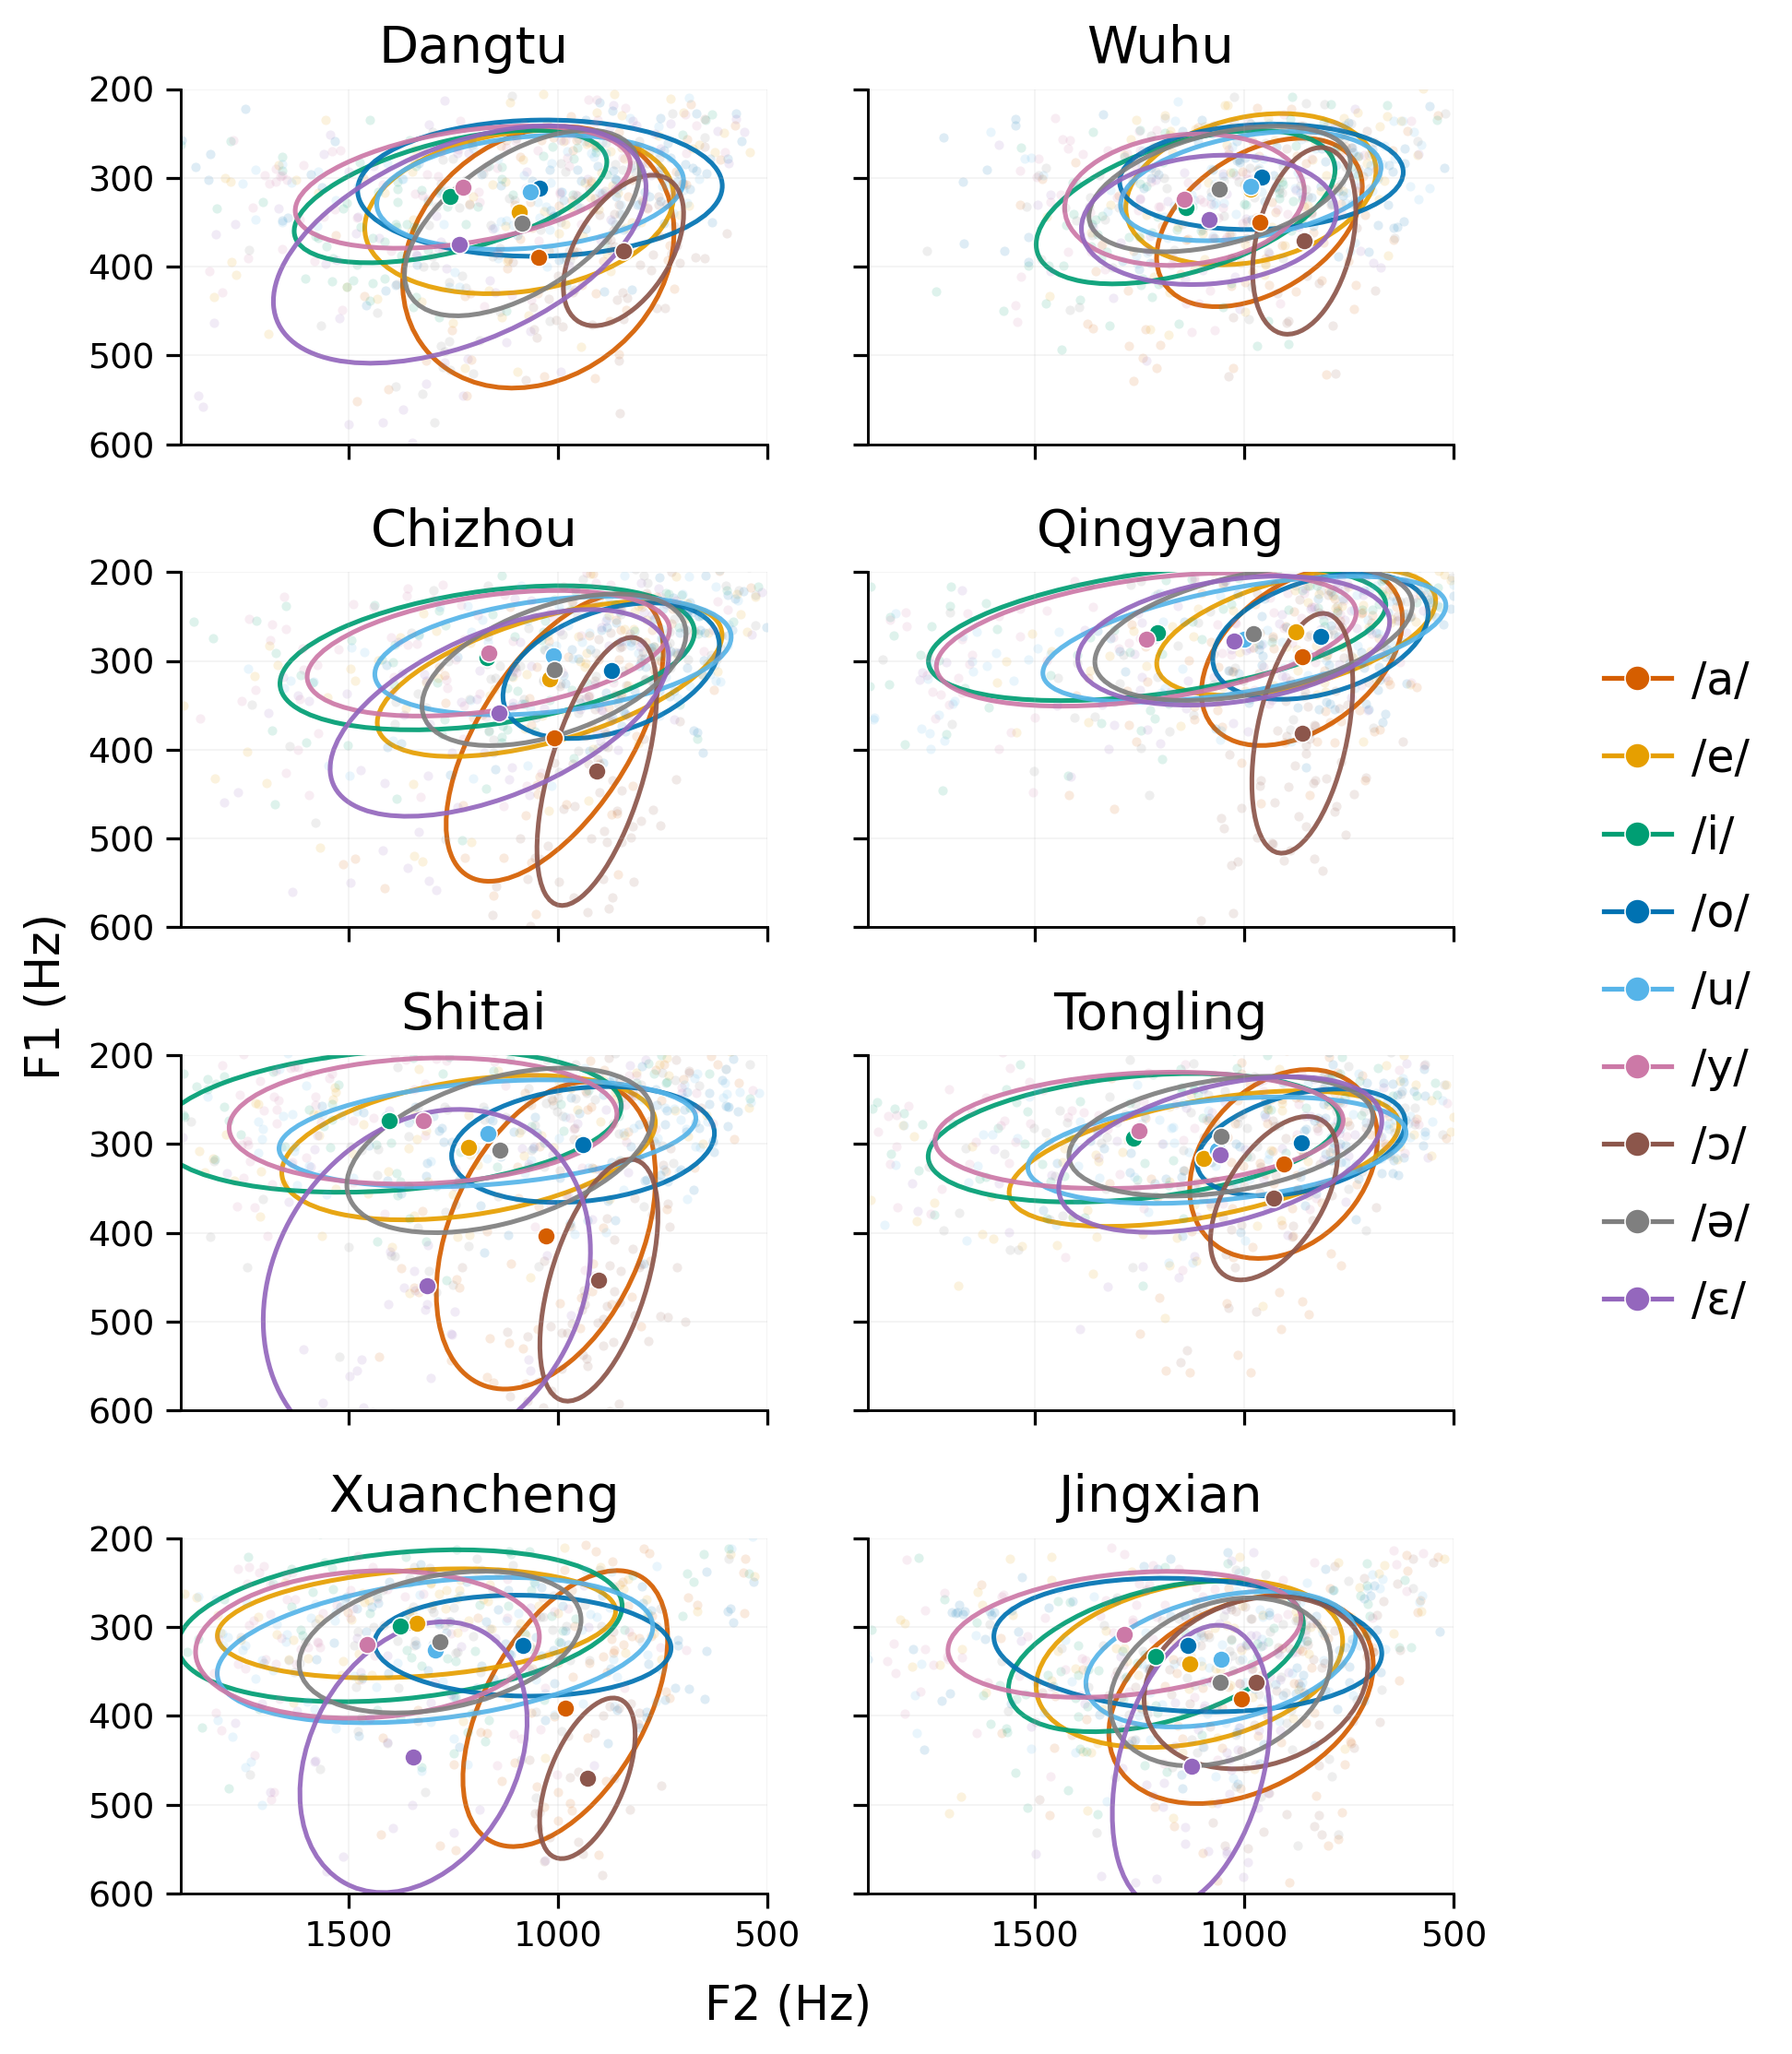


Saved figure files:
png: /home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/fig_8regions_9vowels_4x2_sidelegend_final_v2.png
pdf: /home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/fig_8regions_9vowels_4x2_sidelegend_final_v2.pdf
svg: /home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/fig_8regions_9vowels_4x2_sidelegend_final_v2.svg


In [8]:
# ============================================================
# Wu vowel-space plotting script
# Final compact 4 x 2 layout; compatible with older Python/Jupyter
#
# Functions:
# 1. Read and clean all 14 regions.
# 2. Save metrics for all 14 regions.
# 3. Save metrics for 14 regions x 9 vowels.
# 4. Plot only the selected 8 regions.
# 5. Keep scatter points, ellipses, and center points.
# 6. Use a color legend for 9 vowels.
# 7. No overall title; subplot titles show region names only.
# ============================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse


# ============================================================
# 0. Paths and configuration
# ============================================================

# 保留你修改后的数据路径
CSV_PATH = Path(
    r"/home/ustc1958/lxy/graph/tone/complete_package0614/"
    r"wu_vowel_segments.f1f2_per_audio.csv"
)

# 保留你修改后的保存路径
OUT_DIR = Path(
    r"/home/ustc1958/lxy/graph/tone/complete_package0614/"
    r"pc_dlcmnet_figures_hybrid"
)

OUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 图中只显示这 8 个地区
# 修改这里即可更换图中的 8 个地区
# ------------------------------------------------------------
PLOT_REGION_CODES = [
    "01当涂",
    "02芜湖",
    "03池州",
    "04青阳",
    "05石台",
    "06铜陵",
    "07宣城",
    "08泾县",
]


# 不显示整张图的总标题
SHOW_SUPTITLE = False

# 子图标题只显示地区名，不显示 N
SHOW_N_IN_TITLE = False

# 每个“地区—元音”最多绘制多少个散点
# 只影响图上显示的点数，不影响椭圆、中心点和统计指标
MAX_POINTS_PER_CLUSTER = 70

# 是否保存不同格式
SAVE_PNG = True
SAVE_PDF = True
SAVE_SVG = True


# 9 个元音
VOWELS = [
    "a",
    "e",
    "i",
    "o",
    "u",
    "y",
    "ɔ",
    "ə",
    "ɛ",
]


# 全部 14 个地区
# 统计指标始终使用这里的全部 14 个地区
REGIONS_14 = [
    ("01当涂", "Dangtu"),
    ("02芜湖", "Wuhu"),
    ("03池州", "Chizhou"),
    ("04青阳", "Qingyang"),
    ("05石台", "Shitai"),
    ("06铜陵", "Tongling"),
    ("07宣城", "Xuancheng"),
    ("08泾县", "Jingxian"),
    ("09繁昌", "Fanchang"),
    ("10南陵", "Nanling"),
    ("11黄山", "Huangshan"),
    ("12宁国", "Ningguo"),
    ("13高淳", "Gaochun"),
    ("14溧水", "Lishui"),
]

REGION_NAME_MAP = dict(REGIONS_14)


# 9 个元音的颜色
COLORS = {
    "a": "#D55E00",
    "e": "#E69F00",
    "i": "#009E73",
    "o": "#0072B2",
    "u": "#56B4E9",
    "y": "#CC79A7",
    "ɔ": "#8C564B",
    "ə": "#7F7F7F",
    "ɛ": "#9467BD",
}


# 矢量图中的文字保持可编辑
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


# ============================================================
# 1. Helper functions
# ============================================================

def corrected_region_from_path(wav_path, region_codes):
    """
    根据 wav_path 中的一级地区目录恢复真实地区标签。

    参数
    ----
    wav_path:
        音频文件路径。
    region_codes:
        允许匹配的地区代码列表。

    返回
    ----
    成功匹配时返回地区代码，否则返回 np.nan。
    """
    path_parts = str(wav_path).replace("\\", "/").split("/")
    matches = [
        region_code
        for region_code in region_codes
        if region_code in path_parts
    ]

    if len(matches) == 1:
        return matches[0]

    return np.nan


def robust_filter_region_vowel(df):
    """
    在每个“地区—元音”组内分别对 F1 和 F2 做 IQR 异常值过滤。
    """
    keep_indices = []

    grouped = df.groupby(
        ["paper_region_fixed", "vowel"],
        sort=False,
    )

    for _, group in grouped:
        # 样本过少时不进行 IQR 删除
        if len(group) < 10:
            keep_indices.extend(group.index.tolist())
            continue

        q1_f1 = group["f1_mean_hz"].quantile(0.25)
        q3_f1 = group["f1_mean_hz"].quantile(0.75)
        q1_f2 = group["f2_mean_hz"].quantile(0.25)
        q3_f2 = group["f2_mean_hz"].quantile(0.75)

        iqr_f1 = q3_f1 - q1_f1
        iqr_f2 = q3_f2 - q1_f2

        f1_lower = q1_f1 - 1.5 * iqr_f1
        f1_upper = q3_f1 + 1.5 * iqr_f1
        f2_lower = q1_f2 - 1.5 * iqr_f2
        f2_upper = q3_f2 + 1.5 * iqr_f2

        mask = (
            group["f1_mean_hz"].between(f1_lower, f1_upper)
            & group["f2_mean_hz"].between(f2_lower, f2_upper)
        )

        keep_indices.extend(group.loc[mask].index.tolist())

    keep_indices = sorted(set(keep_indices))
    return df.loc[keep_indices].copy()


def load_and_clean_data(csv_path):
    """
    读取全部 14 个地区的数据并清洗 F1/F2。
    """
    if not csv_path.exists():
        raise FileNotFoundError(
            "CSV file not found: {}".format(csv_path)
        )

    df = pd.read_csv(csv_path)

    required_columns = {
        "wav_path",
        "vowel",
        "f1_mean_hz",
        "f2_mean_hz",
    }

    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        raise ValueError(
            "Missing required columns: {}".format(
                sorted(missing_columns)
            )
        )

    all_region_codes = [
        region_code
        for region_code, _ in REGIONS_14
    ]

    # 根据路径恢复 14 个真实地区标签
    df["paper_region_fixed"] = df["wav_path"].apply(
        lambda wav_path: corrected_region_from_path(
            wav_path,
            all_region_codes,
        )
    )

    # 只保留 14 个地区和 9 个元音
    df = df[
        df["paper_region_fixed"].isin(all_region_codes)
    ].copy()

    df = df[
        df["vowel"].isin(VOWELS)
    ].copy()

    # 转换成数值
    df["f1_mean_hz"] = pd.to_numeric(
        df["f1_mean_hz"],
        errors="coerce",
    )

    df["f2_mean_hz"] = pd.to_numeric(
        df["f2_mean_hz"],
        errors="coerce",
    )

    # 删除缺失值
    df = df.dropna(
        subset=["f1_mean_hz", "f2_mean_hz"]
    )

    # 基本声学合理范围
    valid_mask = (
        df["f1_mean_hz"].between(150, 1200)
        & df["f2_mean_hz"].between(500, 3500)
        & (df["f2_mean_hz"] > df["f1_mean_hz"])
    )

    df = df.loc[valid_mask].copy()

    # 对各地区、各元音分别做稳健异常值过滤
    df = robust_filter_region_vowel(df)

    return df


# ============================================================
# 2. Metrics for all 14 regions
# ============================================================

def safe_group_value(group, column_name, operation):
    """
    对可能不存在的列或空分组安全地计算统计量。
    """
    if group.empty:
        return np.nan

    if column_name not in group.columns:
        return np.nan

    series = group[column_name]

    if operation == "nunique":
        return series.nunique()

    if operation == "mean":
        return series.mean()

    if operation == "std":
        return series.std(ddof=1)

    if operation == "median":
        return series.median()

    raise ValueError(
        "Unsupported operation: {}".format(operation)
    )


def compute_region_summary(df):
    """
    生成全部 14 个地区的整体指标。

    即使某个地区没有有效样本，也会保留该地区的一行，
    以保证输出表始终包含 14 个地区。
    """
    rows = []

    for region_code, region_en in REGIONS_14:
        group = df[
            df["paper_region_fixed"] == region_code
        ]

        row = {
            "paper_region": region_code,
            "region_en": region_en,
            "n_segments": int(len(group)),
            "n_speakers": safe_group_value(
                group,
                "speaker_id",
                "nunique",
            ),
            "n_sites": safe_group_value(
                group,
                "site",
                "nunique",
            ),
            "f1_mean_hz": safe_group_value(
                group,
                "f1_mean_hz",
                "mean",
            ),
            "f1_std_hz": safe_group_value(
                group,
                "f1_mean_hz",
                "std",
            ),
            "f1_median_hz": safe_group_value(
                group,
                "f1_mean_hz",
                "median",
            ),
            "f2_mean_hz": safe_group_value(
                group,
                "f2_mean_hz",
                "mean",
            ),
            "f2_std_hz": safe_group_value(
                group,
                "f2_mean_hz",
                "std",
            ),
            "f2_median_hz": safe_group_value(
                group,
                "f2_mean_hz",
                "median",
            ),
        }

        rows.append(row)

    return pd.DataFrame(rows)


def compute_region_vowel_summary(df):
    """
    生成 14 个地区 × 9 个元音的指标。

    输出始终包含 14 × 9 = 126 行。
    没有有效样本的组合保留为 n_segments=0，其他指标为 NaN。
    """
    rows = []

    for region_code, region_en in REGIONS_14:
        for vowel in VOWELS:
            group = df[
                (df["paper_region_fixed"] == region_code)
                & (df["vowel"] == vowel)
            ]

            row = {
                "paper_region": region_code,
                "region_en": region_en,
                "vowel": vowel,
                "n_segments": int(len(group)),
                "n_speakers": safe_group_value(
                    group,
                    "speaker_id",
                    "nunique",
                ),
                "n_sites": safe_group_value(
                    group,
                    "site",
                    "nunique",
                ),
                "f1_mean_hz": safe_group_value(
                    group,
                    "f1_mean_hz",
                    "mean",
                ),
                "f1_std_hz": safe_group_value(
                    group,
                    "f1_mean_hz",
                    "std",
                ),
                "f1_median_hz": safe_group_value(
                    group,
                    "f1_mean_hz",
                    "median",
                ),
                "f2_mean_hz": safe_group_value(
                    group,
                    "f2_mean_hz",
                    "mean",
                ),
                "f2_std_hz": safe_group_value(
                    group,
                    "f2_mean_hz",
                    "std",
                ),
                "f2_median_hz": safe_group_value(
                    group,
                    "f2_mean_hz",
                    "median",
                ),
            }

            rows.append(row)

    return pd.DataFrame(rows)


# ============================================================
# 3. Plotting
# ============================================================

def add_confidence_ellipse(
    ax,
    x,
    y,
    color,
    scale=1.20,
):
    """
    根据 F2/F1 协方差绘制椭圆。
    """
    if len(x) < 8:
        return

    covariance = np.cov(x, y)

    if not np.all(np.isfinite(covariance)):
        return

    eigenvalues, eigenvectors = np.linalg.eigh(covariance)

    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    angle = np.degrees(
        np.arctan2(
            eigenvectors[1, 0],
            eigenvectors[0, 0],
        )
    )

    width, height = (
        2
        * scale
        * np.sqrt(np.maximum(eigenvalues, 1e-6))
    )

    ellipse = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=angle,
        fill=False,
        edgecolor=color,
        linewidth=1.4,
        alpha=0.92,
    )

    ax.add_patch(ellipse)


def validate_plot_regions():
    """
    检查图中选择的 8 个地区是否合法。
    """
    unknown_codes = [
        region_code
        for region_code in PLOT_REGION_CODES
        if region_code not in REGION_NAME_MAP
    ]

    if unknown_codes:
        raise ValueError(
            "Unknown region codes in PLOT_REGION_CODES: {}".format(
                unknown_codes
            )
        )

    if len(PLOT_REGION_CODES) != 8:
        raise ValueError(
            "PLOT_REGION_CODES must contain exactly 8 regions."
        )

    if len(set(PLOT_REGION_CODES)) != 8:
        raise ValueError(
            "PLOT_REGION_CODES contains duplicated regions."
        )


def get_plot_region_list():
    """
    按 PLOT_REGION_CODES 中给出的顺序返回地区信息。
    """
    validate_plot_regions()

    plot_region_list = []

    for region_code in PLOT_REGION_CODES:
        plot_region_list.append(
            (
                region_code,
                REGION_NAME_MAP[region_code],
            )
        )

    return plot_region_list


def plot_8_regions(df_all):
    """
    只绘制 PLOT_REGION_CODES 指定的 8 个地区。

    使用 4 行 × 2 列主体子图，并为右侧图例单独预留一列。
    这样既不会把子图压得过扁，也不会发生标题或图例溢出。
    """
    plot_region_list = get_plot_region_list()

    plot_region_codes = [
        region_code
        for region_code, _ in plot_region_list
    ]

    df_plot = df_all[
        df_all["paper_region_fixed"].isin(plot_region_codes)
    ].copy()

    if df_plot.empty:
        raise ValueError(
            "No valid data found for the selected 8 regions."
        )

    # --------------------------------------------------------
    # 4×2 主体 + 右侧独立图例列
    # 画布保持纵向比例，并为右侧图例增加独立空间。
    # --------------------------------------------------------
    fig = plt.figure(
        figsize=(7.45, 8.6),
        dpi=260,
    )

    grid = fig.add_gridspec(
        nrows=4,
        ncols=3,
        width_ratios=[1.0, 1.0, 0.34],
        left=0.105,
        right=0.985,
        top=0.965,
        bottom=0.090,
        wspace=0.22,
        hspace=0.36,
    )

    axes = []
    first_ax = None

    for row_index in range(4):
        for col_index in range(2):
            if first_ax is None:
                ax = fig.add_subplot(grid[row_index, col_index])
                first_ax = ax
            else:
                ax = fig.add_subplot(
                    grid[row_index, col_index],
                    sharex=first_ax,
                    sharey=first_ax,
                )

            axes.append(ax)

    legend_ax = fig.add_subplot(grid[:, 2])
    legend_ax.axis("off")

    # 8 个子图统一使用相同的坐标范围
    f2_left = min(
        3200,
        np.ceil(
            df_plot["f2_mean_hz"].quantile(0.98) / 100
        ) * 100,
    )

    f2_right = max(
        500,
        np.floor(
            df_plot["f2_mean_hz"].quantile(0.02) / 100
        ) * 100,
    )

    f1_bottom = min(
        1000,
        np.ceil(
            df_plot["f1_mean_hz"].quantile(0.98) / 50
        ) * 50,
    )

    f1_top = max(
        200,
        np.floor(
            df_plot["f1_mean_hz"].quantile(0.02) / 50
        ) * 50,
    )

    for subplot_index, region_info in enumerate(plot_region_list):
        region_code, region_en = region_info
        ax = axes[subplot_index]

        row_index = subplot_index // 2
        col_index = subplot_index % 2

        region_df = df_plot[
            df_plot["paper_region_fixed"] == region_code
        ]

        for vowel in VOWELS:
            group = region_df.loc[
                region_df["vowel"] == vowel,
                ["f1_mean_hz", "f2_mean_hz"],
            ]

            if group.empty:
                continue

            # 散点只做可视化采样，不影响椭圆和统计指标
            if len(group) > MAX_POINTS_PER_CLUSTER:
                plot_group = group.sample(
                    n=MAX_POINTS_PER_CLUSTER,
                    random_state=42,
                )
            else:
                plot_group = group

            ax.scatter(
                plot_group["f2_mean_hz"],
                plot_group["f1_mean_hz"],
                s=8,
                alpha=0.13,
                color=COLORS[vowel],
                linewidths=0,
                zorder=1,
            )

            add_confidence_ellipse(
                ax=ax,
                x=group["f2_mean_hz"].to_numpy(),
                y=group["f1_mean_hz"].to_numpy(),
                color=COLORS[vowel],
                scale=1.20,
            )

            ax.scatter(
                group["f2_mean_hz"].mean(),
                group["f1_mean_hz"].mean(),
                s=28,
                color=COLORS[vowel],
                edgecolors="white",
                linewidths=0.45,
                zorder=3,
            )

        if SHOW_N_IN_TITLE:
            title_text = "{}\nN={:,}".format(
                region_en,
                len(region_df),
            )
        else:
            title_text = region_en

        ax.set_title(
            title_text,
            fontsize=15.5,
            pad=8,
        )

        # F2 与 F1 均倒置，符合常用元音空间展示方式
        ax.set_xlim(f2_left, f2_right)
        ax.set_ylim(f1_bottom, f1_top)

        ax.grid(
            alpha=0.14,
            linewidth=0.5,
        )

        # 仅左列显示 y 轴刻度，仅最后一行显示 x 轴刻度
        ax.tick_params(
            axis="both",
            which="major",
            labelsize=10.5,
            length=4.5,
            width=0.9,
            labelleft=(col_index == 0),
            labelbottom=(row_index == 3),
        )

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    # 使用全图共享坐标轴标题，避免每行重复占用空间
    fig.text(
        0.445,
        0.035,
        "F2 (Hz)",
        ha="center",
        va="center",
        fontsize=14,
    )

    fig.text(
        0.030,
        0.525,
        "F1 (Hz)",
        ha="center",
        va="center",
        rotation="vertical",
        fontsize=14,
    )

    # 右侧独立图例列：位置略向右，字号适度放大
    legend_handles = []

    for vowel in VOWELS:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color=COLORS[vowel],
                marker="o",
                linestyle="-",
                linewidth=1.45,
                markersize=7.5,
                markerfacecolor=COLORS[vowel],
                markeredgecolor="white",
                markeredgewidth=0.45,
                label="/{}/".format(vowel),
            )
        )

    legend_ax.legend(
        handles=legend_handles,
        loc="center left",
        bbox_to_anchor=(0.16, 0.50),
        ncol=1,
        frameon=False,
        fontsize=13.5,
        handlelength=1.50,
        handletextpad=0.45,
        labelspacing=0.74,
        borderaxespad=0.0,
    )

    if SHOW_SUPTITLE:
        fig.suptitle(
            "Cross-Regional Wu Vowel Space",
            fontsize=20,
            fontweight="bold",
            y=0.995,
        )

    output_paths = {
        "png": OUT_DIR / "fig_8regions_9vowels_4x2_sidelegend_final_v2.png",
        "pdf": OUT_DIR / "fig_8regions_9vowels_4x2_sidelegend_final_v2.pdf",
        "svg": OUT_DIR / "fig_8regions_9vowels_4x2_sidelegend_final_v2.svg",
    }

    if SAVE_PNG:
        fig.savefig(
            output_paths["png"],
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.03,
        )

    if SAVE_PDF:
        fig.savefig(
            output_paths["pdf"],
            bbox_inches="tight",
            pad_inches=0.03,
        )

    if SAVE_SVG:
        fig.savefig(
            output_paths["svg"],
            bbox_inches="tight",
            pad_inches=0.03,
        )

    plt.show()
    plt.close(fig)

    saved_paths = {}

    if SAVE_PNG:
        saved_paths["png"] = output_paths["png"]
    if SAVE_PDF:
        saved_paths["pdf"] = output_paths["pdf"]
    if SAVE_SVG:
        saved_paths["svg"] = output_paths["svg"]

    return saved_paths


# ============================================================
# 4. Main
# ============================================================

def main():
    """
    先用全部 14 个地区计算指标，
    再只使用指定的 8 个地区绘图。
    """
    print("CSV path:")
    print(CSV_PATH)

    print("\nOutput directory:")
    print(OUT_DIR)

    # --------------------------------------------------------
    # A. 加载全部 14 个地区
    # --------------------------------------------------------
    df_all = load_and_clean_data(CSV_PATH)

    print(
        "\nCleaned rows from all 14 regions: {:,}".format(
            len(df_all)
        )
    )

    # --------------------------------------------------------
    # B. 保存全部 14 个地区的整体指标
    # --------------------------------------------------------
    region_summary = compute_region_summary(df_all)

    region_summary_path = (
        OUT_DIR / "region_summary_14regions.csv"
    )

    region_summary.to_csv(
        region_summary_path,
        index=False,
        encoding="utf-8-sig",
    )

    # --------------------------------------------------------
    # C. 保存 14 地区 × 9 元音指标
    # --------------------------------------------------------
    region_vowel_summary = compute_region_vowel_summary(df_all)

    region_vowel_summary_path = (
        OUT_DIR
        / "region_vowel_summary_14regions_9vowels.csv"
    )

    region_vowel_summary.to_csv(
        region_vowel_summary_path,
        index=False,
        encoding="utf-8-sig",
    )

    print("\nSaved metric files:")
    print(region_summary_path)
    print(region_vowel_summary_path)

    print(
        "Region summary rows: {}".format(
            len(region_summary)
        )
    )

    print(
        "Region-vowel summary rows: {}".format(
            len(region_vowel_summary)
        )
    )

    # --------------------------------------------------------
    # D. 只画配置中的 8 个地区
    # --------------------------------------------------------
    print("\nRegions used in the figure:")

    for region_code in PLOT_REGION_CODES:
        print(
            "{}  {}".format(
                region_code,
                REGION_NAME_MAP[region_code],
            )
        )

    figure_paths = plot_8_regions(df_all)

    print("\nSaved figure files:")

    for file_type, file_path in figure_paths.items():
        print(
            "{}: {}".format(
                file_type,
                file_path,
            )
        )


# 在 .py 和 ipynb 中都可以直接运行
main()

CSV path:
/home/ustc1958/lxy/graph/tone/complete_package0614/wu_vowel_segments.f1f2_per_audio.csv

Output directory:
/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid

Cleaned rows from all 14 regions: 43,905

Saved metric files:
/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/region_summary_14regions.csv
/home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/region_vowel_summary_14regions_9vowels.csv
Region summary rows: 14
Region-vowel summary rows: 126

Regions used in the figure:
01当涂  Dangtu
02芜湖  Wuhu
03池州  Chizhou
04青阳  Qingyang
05石台  Shitai
06铜陵  Tongling
07宣城  Xuancheng
08泾县  Jingxian


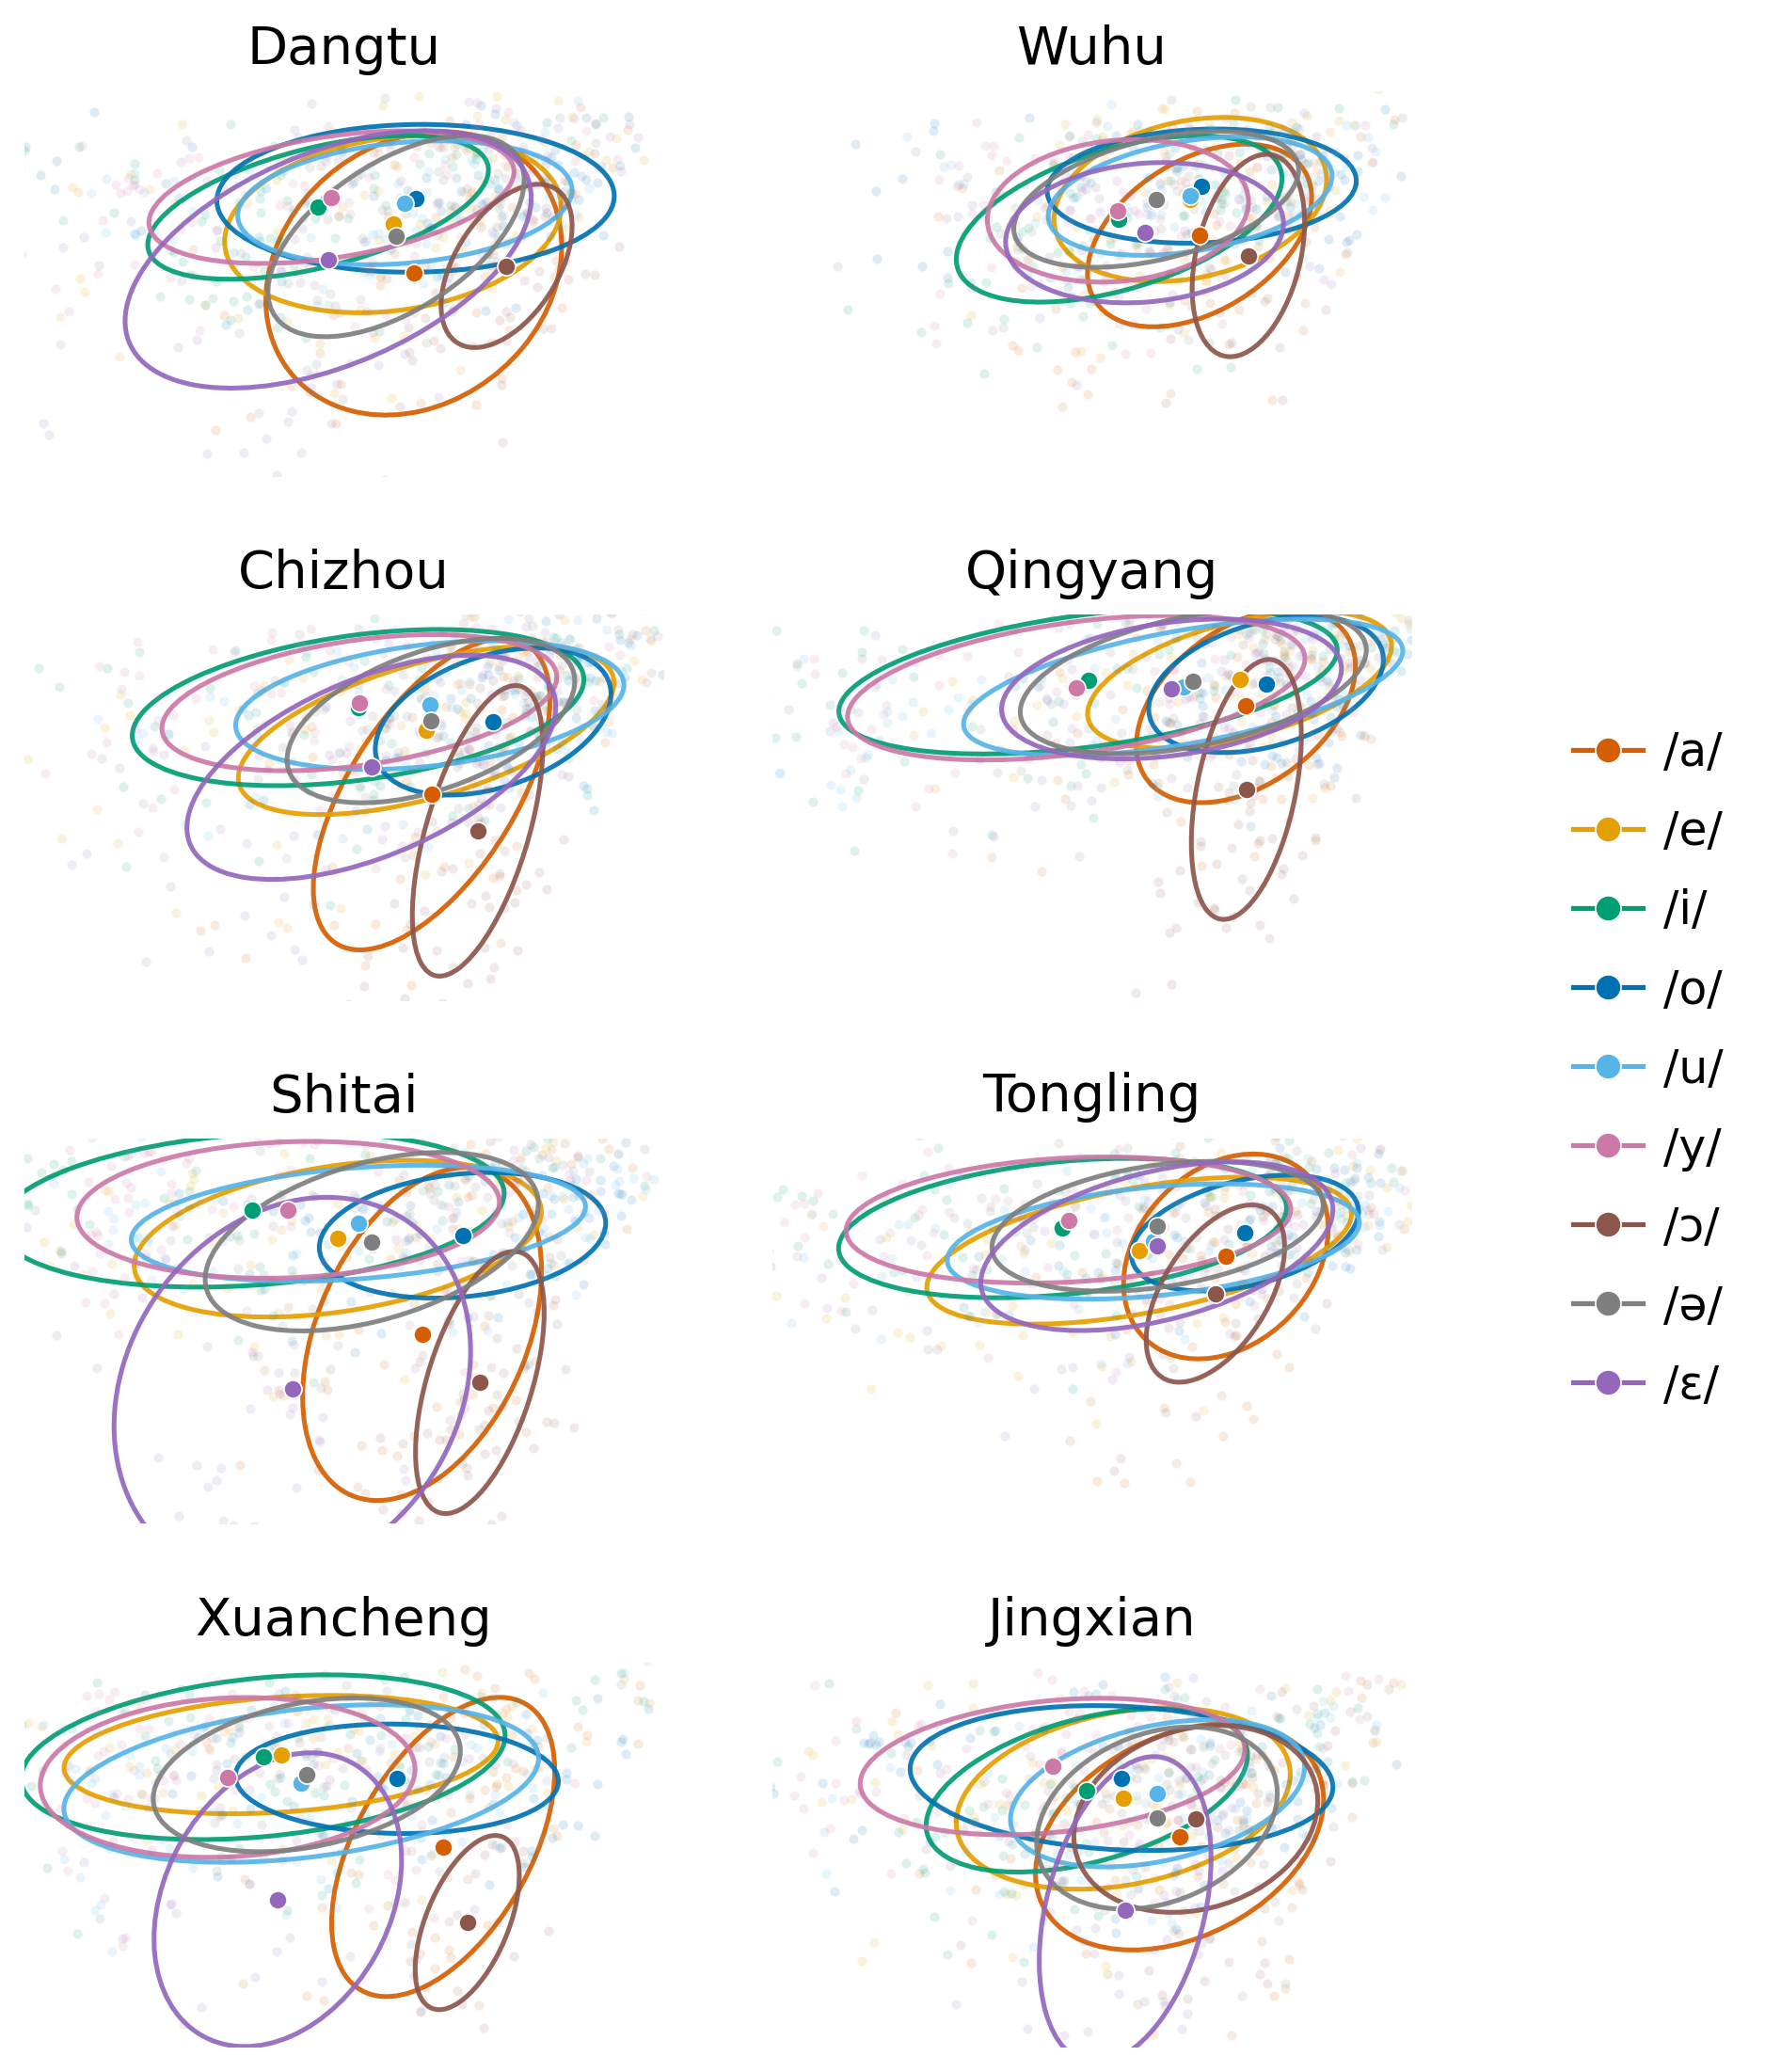


Saved figure files:
png: /home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/fig_8regions_9vowels_4x2_sidelegend_no_axes.png
pdf: /home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/fig_8regions_9vowels_4x2_sidelegend_no_axes.pdf
svg: /home/ustc1958/lxy/graph/tone/complete_package0614/pc_dlcmnet_figures_hybrid/fig_8regions_9vowels_4x2_sidelegend_no_axes.svg


In [1]:



from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse


# ============================================================
# 0. Paths and configuration
# ============================================================

# 保留你修改后的数据路径
CSV_PATH = Path(
    r"/home/ustc1958/lxy/graph/tone/complete_package0614/"
    r"wu_vowel_segments.f1f2_per_audio.csv"
)

# 保留你修改后的保存路径
OUT_DIR = Path(
    r"/home/ustc1958/lxy/graph/tone/complete_package0614/"
    r"pc_dlcmnet_figures_hybrid"
)

OUT_DIR.mkdir(parents=True, exist_ok=True)


# ------------------------------------------------------------
# 图中只显示这 8 个地区
# 修改这里即可更换图中的 8 个地区
# ------------------------------------------------------------
PLOT_REGION_CODES = [
    "01当涂",
    "02芜湖",
    "03池州",
    "04青阳",
    "05石台",
    "06铜陵",
    "07宣城",
    "08泾县",
]


# 不显示整张图的总标题
SHOW_SUPTITLE = False

# 子图标题只显示地区名，不显示 N
SHOW_N_IN_TITLE = False

# 每个“地区—元音”最多绘制多少个散点
# 只影响图上显示的点数，不影响椭圆、中心点和统计指标
MAX_POINTS_PER_CLUSTER = 70

# 是否保存不同格式
SAVE_PNG = True
SAVE_PDF = True
SAVE_SVG = True


# 9 个元音
VOWELS = [
    "a",
    "e",
    "i",
    "o",
    "u",
    "y",
    "ɔ",
    "ə",
    "ɛ",
]


# 全部 14 个地区
# 统计指标始终使用这里的全部 14 个地区
REGIONS_14 = [
    ("01当涂", "Dangtu"),
    ("02芜湖", "Wuhu"),
    ("03池州", "Chizhou"),
    ("04青阳", "Qingyang"),
    ("05石台", "Shitai"),
    ("06铜陵", "Tongling"),
    ("07宣城", "Xuancheng"),
    ("08泾县", "Jingxian"),
    ("09繁昌", "Fanchang"),
    ("10南陵", "Nanling"),
    ("11黄山", "Huangshan"),
    ("12宁国", "Ningguo"),
    ("13高淳", "Gaochun"),
    ("14溧水", "Lishui"),
]

REGION_NAME_MAP = dict(REGIONS_14)


# 9 个元音的颜色
COLORS = {
    "a": "#D55E00",
    "e": "#E69F00",
    "i": "#009E73",
    "o": "#0072B2",
    "u": "#56B4E9",
    "y": "#CC79A7",
    "ɔ": "#8C564B",
    "ə": "#7F7F7F",
    "ɛ": "#9467BD",
}


# 矢量图中的文字保持可编辑
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42


# ============================================================
# 1. Helper functions
# ============================================================

def corrected_region_from_path(wav_path, region_codes):
    """
    根据 wav_path 中的一级地区目录恢复真实地区标签。

    参数
    ----
    wav_path:
        音频文件路径。
    region_codes:
        允许匹配的地区代码列表。

    返回
    ----
    成功匹配时返回地区代码，否则返回 np.nan。
    """
    path_parts = str(wav_path).replace("\\", "/").split("/")
    matches = [
        region_code
        for region_code in region_codes
        if region_code in path_parts
    ]

    if len(matches) == 1:
        return matches[0]

    return np.nan


def robust_filter_region_vowel(df):
    """
    在每个“地区—元音”组内分别对 F1 和 F2 做 IQR 异常值过滤。
    """
    keep_indices = []

    grouped = df.groupby(
        ["paper_region_fixed", "vowel"],
        sort=False,
    )

    for _, group in grouped:
        # 样本过少时不进行 IQR 删除
        if len(group) < 10:
            keep_indices.extend(group.index.tolist())
            continue

        q1_f1 = group["f1_mean_hz"].quantile(0.25)
        q3_f1 = group["f1_mean_hz"].quantile(0.75)
        q1_f2 = group["f2_mean_hz"].quantile(0.25)
        q3_f2 = group["f2_mean_hz"].quantile(0.75)

        iqr_f1 = q3_f1 - q1_f1
        iqr_f2 = q3_f2 - q1_f2

        f1_lower = q1_f1 - 1.5 * iqr_f1
        f1_upper = q3_f1 + 1.5 * iqr_f1
        f2_lower = q1_f2 - 1.5 * iqr_f2
        f2_upper = q3_f2 + 1.5 * iqr_f2

        mask = (
            group["f1_mean_hz"].between(f1_lower, f1_upper)
            & group["f2_mean_hz"].between(f2_lower, f2_upper)
        )

        keep_indices.extend(group.loc[mask].index.tolist())

    keep_indices = sorted(set(keep_indices))
    return df.loc[keep_indices].copy()


def load_and_clean_data(csv_path):
    """
    读取全部 14 个地区的数据并清洗 F1/F2。
    """
    if not csv_path.exists():
        raise FileNotFoundError(
            "CSV file not found: {}".format(csv_path)
        )

    df = pd.read_csv(csv_path)

    required_columns = {
        "wav_path",
        "vowel",
        "f1_mean_hz",
        "f2_mean_hz",
    }

    missing_columns = required_columns.difference(df.columns)

    if missing_columns:
        raise ValueError(
            "Missing required columns: {}".format(
                sorted(missing_columns)
            )
        )

    all_region_codes = [
        region_code
        for region_code, _ in REGIONS_14
    ]

    # 根据路径恢复 14 个真实地区标签
    df["paper_region_fixed"] = df["wav_path"].apply(
        lambda wav_path: corrected_region_from_path(
            wav_path,
            all_region_codes,
        )
    )

    # 只保留 14 个地区和 9 个元音
    df = df[
        df["paper_region_fixed"].isin(all_region_codes)
    ].copy()

    df = df[
        df["vowel"].isin(VOWELS)
    ].copy()

    # 转换成数值
    df["f1_mean_hz"] = pd.to_numeric(
        df["f1_mean_hz"],
        errors="coerce",
    )

    df["f2_mean_hz"] = pd.to_numeric(
        df["f2_mean_hz"],
        errors="coerce",
    )

    # 删除缺失值
    df = df.dropna(
        subset=["f1_mean_hz", "f2_mean_hz"]
    )

    # 基本声学合理范围
    valid_mask = (
        df["f1_mean_hz"].between(150, 1200)
        & df["f2_mean_hz"].between(500, 3500)
        & (df["f2_mean_hz"] > df["f1_mean_hz"])
    )

    df = df.loc[valid_mask].copy()

    # 对各地区、各元音分别做稳健异常值过滤
    df = robust_filter_region_vowel(df)

    return df


# ============================================================
# 2. Metrics for all 14 regions
# ============================================================

def safe_group_value(group, column_name, operation):
    """
    对可能不存在的列或空分组安全地计算统计量。
    """
    if group.empty:
        return np.nan

    if column_name not in group.columns:
        return np.nan

    series = group[column_name]

    if operation == "nunique":
        return series.nunique()

    if operation == "mean":
        return series.mean()

    if operation == "std":
        return series.std(ddof=1)

    if operation == "median":
        return series.median()

    raise ValueError(
        "Unsupported operation: {}".format(operation)
    )


def compute_region_summary(df):
    """
    生成全部 14 个地区的整体指标。

    即使某个地区没有有效样本，也会保留该地区的一行，
    以保证输出表始终包含 14 个地区。
    """
    rows = []

    for region_code, region_en in REGIONS_14:
        group = df[
            df["paper_region_fixed"] == region_code
        ]

        row = {
            "paper_region": region_code,
            "region_en": region_en,
            "n_segments": int(len(group)),
            "n_speakers": safe_group_value(
                group,
                "speaker_id",
                "nunique",
            ),
            "n_sites": safe_group_value(
                group,
                "site",
                "nunique",
            ),
            "f1_mean_hz": safe_group_value(
                group,
                "f1_mean_hz",
                "mean",
            ),
            "f1_std_hz": safe_group_value(
                group,
                "f1_mean_hz",
                "std",
            ),
            "f1_median_hz": safe_group_value(
                group,
                "f1_mean_hz",
                "median",
            ),
            "f2_mean_hz": safe_group_value(
                group,
                "f2_mean_hz",
                "mean",
            ),
            "f2_std_hz": safe_group_value(
                group,
                "f2_mean_hz",
                "std",
            ),
            "f2_median_hz": safe_group_value(
                group,
                "f2_mean_hz",
                "median",
            ),
        }

        rows.append(row)

    return pd.DataFrame(rows)


def compute_region_vowel_summary(df):
    """
    生成 14 个地区 × 9 个元音的指标。

    输出始终包含 14 × 9 = 126 行。
    没有有效样本的组合保留为 n_segments=0，其他指标为 NaN。
    """
    rows = []

    for region_code, region_en in REGIONS_14:
        for vowel in VOWELS:
            group = df[
                (df["paper_region_fixed"] == region_code)
                & (df["vowel"] == vowel)
            ]

            row = {
                "paper_region": region_code,
                "region_en": region_en,
                "vowel": vowel,
                "n_segments": int(len(group)),
                "n_speakers": safe_group_value(
                    group,
                    "speaker_id",
                    "nunique",
                ),
                "n_sites": safe_group_value(
                    group,
                    "site",
                    "nunique",
                ),
                "f1_mean_hz": safe_group_value(
                    group,
                    "f1_mean_hz",
                    "mean",
                ),
                "f1_std_hz": safe_group_value(
                    group,
                    "f1_mean_hz",
                    "std",
                ),
                "f1_median_hz": safe_group_value(
                    group,
                    "f1_mean_hz",
                    "median",
                ),
                "f2_mean_hz": safe_group_value(
                    group,
                    "f2_mean_hz",
                    "mean",
                ),
                "f2_std_hz": safe_group_value(
                    group,
                    "f2_mean_hz",
                    "std",
                ),
                "f2_median_hz": safe_group_value(
                    group,
                    "f2_mean_hz",
                    "median",
                ),
            }

            rows.append(row)

    return pd.DataFrame(rows)


# ============================================================
# 3. Plotting
# ============================================================

def add_confidence_ellipse(
    ax,
    x,
    y,
    color,
    scale=1.20,
):
    """
    根据 F2/F1 协方差绘制椭圆。
    """
    if len(x) < 8:
        return

    covariance = np.cov(x, y)

    if not np.all(np.isfinite(covariance)):
        return

    eigenvalues, eigenvectors = np.linalg.eigh(covariance)

    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    angle = np.degrees(
        np.arctan2(
            eigenvectors[1, 0],
            eigenvectors[0, 0],
        )
    )

    width, height = (
        2
        * scale
        * np.sqrt(np.maximum(eigenvalues, 1e-6))
    )

    ellipse = Ellipse(
        xy=(np.mean(x), np.mean(y)),
        width=width,
        height=height,
        angle=angle,
        fill=False,
        edgecolor=color,
        linewidth=1.4,
        alpha=0.92,
    )

    ax.add_patch(ellipse)


def validate_plot_regions():
    """
    检查图中选择的 8 个地区是否合法。
    """
    unknown_codes = [
        region_code
        for region_code in PLOT_REGION_CODES
        if region_code not in REGION_NAME_MAP
    ]

    if unknown_codes:
        raise ValueError(
            "Unknown region codes in PLOT_REGION_CODES: {}".format(
                unknown_codes
            )
        )

    if len(PLOT_REGION_CODES) != 8:
        raise ValueError(
            "PLOT_REGION_CODES must contain exactly 8 regions."
        )

    if len(set(PLOT_REGION_CODES)) != 8:
        raise ValueError(
            "PLOT_REGION_CODES contains duplicated regions."
        )


def get_plot_region_list():
    """
    按 PLOT_REGION_CODES 中给出的顺序返回地区信息。
    """
    validate_plot_regions()

    plot_region_list = []

    for region_code in PLOT_REGION_CODES:
        plot_region_list.append(
            (
                region_code,
                REGION_NAME_MAP[region_code],
            )
        )

    return plot_region_list


def plot_8_regions(df_all):
    """
    只绘制 PLOT_REGION_CODES 指定的 8 个地区。

    使用 4 行 × 2 列主体子图，并为右侧图例单独预留一列。
    这样既不会把子图压得过扁，也不会发生标题或图例溢出。
    """
    plot_region_list = get_plot_region_list()

    plot_region_codes = [
        region_code
        for region_code, _ in plot_region_list
    ]

    df_plot = df_all[
        df_all["paper_region_fixed"].isin(plot_region_codes)
    ].copy()

    if df_plot.empty:
        raise ValueError(
            "No valid data found for the selected 8 regions."
        )

    # --------------------------------------------------------
    # 4×2 主体 + 右侧独立图例列
    # 画布保持纵向比例，并为右侧图例增加独立空间。
    # --------------------------------------------------------
    fig = plt.figure(
        figsize=(7.45, 8.6),
        dpi=260,
    )

    grid = fig.add_gridspec(
        nrows=4,
        ncols=3,
        width_ratios=[1.0, 1.0, 0.34],
        left=0.045,
        right=0.985,
        top=0.965,
        bottom=0.035,
        wspace=0.22,
        hspace=0.36,
    )

    axes = []
    first_ax = None

    for row_index in range(4):
        for col_index in range(2):
            if first_ax is None:
                ax = fig.add_subplot(grid[row_index, col_index])
                first_ax = ax
            else:
                ax = fig.add_subplot(
                    grid[row_index, col_index],
                    sharex=first_ax,
                    sharey=first_ax,
                )

            axes.append(ax)

    legend_ax = fig.add_subplot(grid[:, 2])
    legend_ax.axis("off")

    # 8 个子图统一使用相同的坐标范围
    f2_left = min(
        3200,
        np.ceil(
            df_plot["f2_mean_hz"].quantile(0.98) / 100
        ) * 100,
    )

    f2_right = max(
        500,
        np.floor(
            df_plot["f2_mean_hz"].quantile(0.02) / 100
        ) * 100,
    )

    f1_bottom = min(
        1000,
        np.ceil(
            df_plot["f1_mean_hz"].quantile(0.98) / 50
        ) * 50,
    )

    f1_top = max(
        200,
        np.floor(
            df_plot["f1_mean_hz"].quantile(0.02) / 50
        ) * 50,
    )

    for subplot_index, region_info in enumerate(plot_region_list):
        region_code, region_en = region_info
        ax = axes[subplot_index]

        row_index = subplot_index // 2
        col_index = subplot_index % 2

        region_df = df_plot[
            df_plot["paper_region_fixed"] == region_code
        ]

        for vowel in VOWELS:
            group = region_df.loc[
                region_df["vowel"] == vowel,
                ["f1_mean_hz", "f2_mean_hz"],
            ]

            if group.empty:
                continue

            # 散点只做可视化采样，不影响椭圆和统计指标
            if len(group) > MAX_POINTS_PER_CLUSTER:
                plot_group = group.sample(
                    n=MAX_POINTS_PER_CLUSTER,
                    random_state=42,
                )
            else:
                plot_group = group

            ax.scatter(
                plot_group["f2_mean_hz"],
                plot_group["f1_mean_hz"],
                s=8,
                alpha=0.13,
                color=COLORS[vowel],
                linewidths=0,
                zorder=1,
            )

            add_confidence_ellipse(
                ax=ax,
                x=group["f2_mean_hz"].to_numpy(),
                y=group["f1_mean_hz"].to_numpy(),
                color=COLORS[vowel],
                scale=1.20,
            )

            ax.scatter(
                group["f2_mean_hz"].mean(),
                group["f1_mean_hz"].mean(),
                s=28,
                color=COLORS[vowel],
                edgecolors="white",
                linewidths=0.45,
                zorder=3,
            )

        if SHOW_N_IN_TITLE:
            title_text = "{}\nN={:,}".format(
                region_en,
                len(region_df),
            )
        else:
            title_text = region_en

        ax.set_title(
            title_text,
            fontsize=15.5,
            pad=8,
        )

        # F2 与 F1 均倒置，符合常用元音空间展示方式
        ax.set_xlim(f2_left, f2_right)
        ax.set_ylim(f1_bottom, f1_top)

        # 完全移除坐标轴视觉元素：
        # 不显示网格、刻度、刻度文字、轴线和坐标轴标题
        ax.grid(False)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.tick_params(
            axis="both",
            which="both",
            bottom=False,
            top=False,
            left=False,
            right=False,
            labelbottom=False,
            labelleft=False,
        )

        for spine in ax.spines.values():
            spine.set_visible(False)

    # 右侧独立图例列：位置略向右，字号适度放大
    legend_handles = []

    for vowel in VOWELS:
        legend_handles.append(
            Line2D(
                [0],
                [0],
                color=COLORS[vowel],
                marker="o",
                linestyle="-",
                linewidth=1.45,
                markersize=7.5,
                markerfacecolor=COLORS[vowel],
                markeredgecolor="white",
                markeredgewidth=0.45,
                label="/{}/".format(vowel),
            )
        )

    legend_ax.legend(
        handles=legend_handles,
        loc="center left",
        bbox_to_anchor=(0.16, 0.50),
        ncol=1,
        frameon=False,
        fontsize=13.5,
        handlelength=1.50,
        handletextpad=0.45,
        labelspacing=0.74,
        borderaxespad=0.0,
    )

    if SHOW_SUPTITLE:
        fig.suptitle(
            "Cross-Regional Wu Vowel Space",
            fontsize=20,
            fontweight="bold",
            y=0.995,
        )

    output_paths = {
        "png": OUT_DIR / "fig_8regions_9vowels_4x2_sidelegend_no_axes.png",
        "pdf": OUT_DIR / "fig_8regions_9vowels_4x2_sidelegend_no_axes.pdf",
        "svg": OUT_DIR / "fig_8regions_9vowels_4x2_sidelegend_no_axes.svg",
    }

    if SAVE_PNG:
        fig.savefig(
            output_paths["png"],
            dpi=300,
            bbox_inches="tight",
            pad_inches=0.03,
        )

    if SAVE_PDF:
        fig.savefig(
            output_paths["pdf"],
            bbox_inches="tight",
            pad_inches=0.03,
        )

    if SAVE_SVG:
        fig.savefig(
            output_paths["svg"],
            bbox_inches="tight",
            pad_inches=0.03,
        )

    plt.show()
    plt.close(fig)

    saved_paths = {}

    if SAVE_PNG:
        saved_paths["png"] = output_paths["png"]
    if SAVE_PDF:
        saved_paths["pdf"] = output_paths["pdf"]
    if SAVE_SVG:
        saved_paths["svg"] = output_paths["svg"]

    return saved_paths


# ============================================================
# 4. Main
# ============================================================

def main():
    """
    先用全部 14 个地区计算指标，
    再只使用指定的 8 个地区绘图。
    """
    print("CSV path:")
    print(CSV_PATH)

    print("\nOutput directory:")
    print(OUT_DIR)

    # --------------------------------------------------------
    # A. 加载全部 14 个地区
    # --------------------------------------------------------
    df_all = load_and_clean_data(CSV_PATH)

    print(
        "\nCleaned rows from all 14 regions: {:,}".format(
            len(df_all)
        )
    )

    # --------------------------------------------------------
    # B. 保存全部 14 个地区的整体指标
    # --------------------------------------------------------
    region_summary = compute_region_summary(df_all)

    region_summary_path = (
        OUT_DIR / "region_summary_14regions.csv"
    )

    region_summary.to_csv(
        region_summary_path,
        index=False,
        encoding="utf-8-sig",
    )

    # --------------------------------------------------------
    # C. 保存 14 地区 × 9 元音指标
    # --------------------------------------------------------
    region_vowel_summary = compute_region_vowel_summary(df_all)

    region_vowel_summary_path = (
        OUT_DIR
        / "region_vowel_summary_14regions_9vowels.csv"
    )

    region_vowel_summary.to_csv(
        region_vowel_summary_path,
        index=False,
        encoding="utf-8-sig",
    )

    print("\nSaved metric files:")
    print(region_summary_path)
    print(region_vowel_summary_path)

    print(
        "Region summary rows: {}".format(
            len(region_summary)
        )
    )

    print(
        "Region-vowel summary rows: {}".format(
            len(region_vowel_summary)
        )
    )

    # --------------------------------------------------------
    # D. 只画配置中的 8 个地区
    # --------------------------------------------------------
    print("\nRegions used in the figure:")

    for region_code in PLOT_REGION_CODES:
        print(
            "{}  {}".format(
                region_code,
                REGION_NAME_MAP[region_code],
            )
        )

    figure_paths = plot_8_regions(df_all)

    print("\nSaved figure files:")

    for file_type, file_path in figure_paths.items():
        print(
            "{}: {}".format(
                file_type,
                file_path,
            )
        )


# 在 .py 和 ipynb 中都可以直接运行
main()